# Search: Solving a Maze Using a Goal-based Agent

Student Name: Devarsh Shah

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: DS


## Learning Outcomes

* Formulate search problems using key components like initial state, actions, and goal state in a deterministic, fully observable environment.
* Implement and compare search algorithms including BFS, DFS, GBFS, A*, and IDS for planning paths through mazes.
* Analyze algorithm performance by measuring path cost, node expansions, depth, and memory usage across various maze types.
* Use visualization tools to represent maze paths and support debugging and analysis.

## Instructions

Total Points: Undergrads 100 + 5 bonus / Graduate students 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the notebook file and the completely rendered notebook with all outputs as a HTML file.


## Introduction

In this exercise, we will implement the planning function for a type of goal-based agent called a __planning agent__. The planning function uses a map it is given to plan a path through the maze from the starting location $S$ to the goal location $G$. We will only focus on the planning function, so you do not need to implement an environment, just use the map to search for a path to solve the maze.

Once the plan is made, the agent in a deterministic environment (i.e., the transition function is deterministic with the outcome of each state/action pair fixed and no randomness) can just follow the plan step-by-step and does not need to care about the percepts.
This is also called an **[open-loop system](https://en.wikipedia.org/wiki/Open-loop_controller).**
The execution phase is trivial and can be executed using a model-based reflex agent
that ignores all percepts and just follows the plan. I will show you a short example, but you do not implement it in this exercise.

Given that the agent has a complete and correct map, the environment is **fully observable, discrete, deterministic, and known.**
Remember:

* **Fully observable** means that the agent can see its state and what the available actions are. That means the **percepts contain the complete current state.**
Here, during planning, the agent always sees its x and y coordinates on the map and
also seeks when it has reached the goal state.
* **Discrete** means that we have a **finite set of states.** The maze has a finite set
of squares the agent can be in.
* **Deterministic** means that the **transition function contains no randomness.** An action in a state will always produce the same result. Going south from the start state always will lead to the same square.
* **Know** means that the agent **knows the complete transition function.** The
agent has the map and therefore knows how its position changes when it walks in a direction.

Tree search algorithm implementations that you find online typically come from data structures courses and have a different aim than AI tree search. These algorithms assume that you already have a tree in memory. We are interested in dynamically creating a search tree with the aim of finding a good/the best path from the root note to the goal state. Follow the pseudo code presented in the text book (and replicated in the slides) closely. Ideally, we would like to search only a small part of the maze, i.e., create a search tree with as few nodes as possible.

Several mazes for this exercise are stored as text files. We need to make sure that they are locally available.

In [1]:
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)

base_url = "https://raw.githubusercontent.com/mhahsler/Introduction_to_Artificial_Intelligence/refs/heads/master/Search/"
download("maze_helper.py", base_url)

mazes = ["small_maze.txt", "medium_maze.txt", "large_maze.txt", "L_maze.txt", "empty_maze.txt", "empty_maze_2.txt", "loops_maze.txt", "open_maze.txt", ]
for maze in mazes:
    download(maze, base_url)

Here is the small example maze:

In [2]:
with open("small_maze.txt", "r") as f:
    maze_str = f.read()
print(maze_str)

XXXXXXXXXXXXXXXXXXXXXX
X XX        X X      X
X    XXXXXX X XXXXXX X
XXXXXX     S  X      X
X    X XXXXXX XX XXXXX
X XXXX X         X   X
X        XXX XXX   X X
XXXXXXXXXX    XXXXXX X
XG         XX        X
XXXXXXXXXXXXXXXXXXXXXX



**Note:** If you get an error here that the file cannot be found, then you need to download it. See [HOWTO Work on Assignments.](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/working_on_assignments.md)

## Parsing and pretty printing the maze

The maze can also be displayed in color using code in the module [maze_helper.py](maze_helper.py). The code parses the string representing the maze and converts it into a `numpy` 2d array which you can use in your implementation. Position are represented as a 2-tuple of the form `(row, col)`.

In [3]:
import maze_helper as mh

maze = mh.parse_maze(maze_str)

# look at a position in the maze by subsetting the 2d array
print("Position(0,0):", maze[0, 0])

# there is also a helper function called `look(maze, pos)` available
# which uses a 2-tuple for the position.
print("Position(8,1):", mh.look(maze, (8, 1)))

Position(0,0): X
Position(8,1): G


A helper function to visualize the maze is also available.

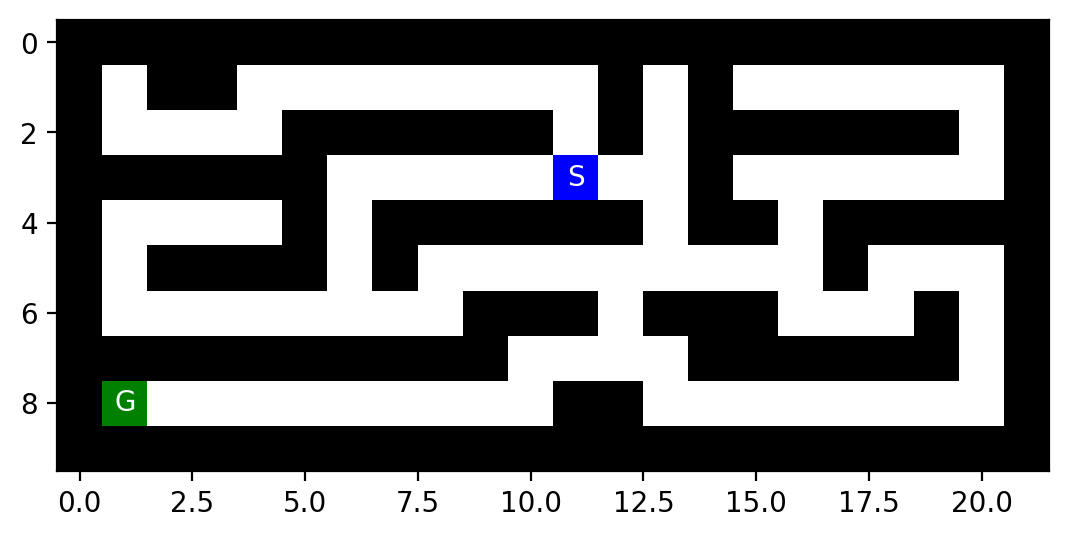

In [4]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# use higher resolution images in notebooks

mh.show_maze(maze)

Find the `(x,y)` position of the start and the goal using the helper function `find_pos()`

In [5]:
print("Start location:", mh.find_pos(maze, what = "S"))
print("Goal location:", mh.find_pos(maze, what = "G"))

Start location: (np.int64(3), np.int64(11))
Goal location: (np.int64(8), np.int64(1))


Helper function documentation.

In [6]:
help(mh)

Help on module maze_helper:

NAME
    maze_helper

DESCRIPTION
    Code for the Maze Assignment by Michael Hahsler
    Usage:
        import maze_helper as mh
        mh.show_some_mazes()

FUNCTIONS
    animate_maze(result, repeat=False)
        (Experimental) Build an animation from a list of mazes. This needs ffmpeg to be installed.

        Parameters:
            result: a list with the elements path, reached, actions and maze_anim with a list of maze arrays that contain what you want to visualize.
            repeat: if True, the animation will repeat.

    find_pos(maze, what='S')
        Find start/goal in a maze and returns the first one.
        Caution: there is no error checking!

        Parameters:
            maze: a array with characters produced by parse_maze()
            what: the letter to be found ('S' for start and 'G' for goal)

        Returns:
            a tupple (x, y) for the found position.

    look(maze, pos)
        Look at the label of a square with the 

You will need to make a local copy of the module file [maze_helper.py](maze_helper.py) in the same folder where your notebook is.

## An Example for a Planning Agent

I will show you here how to implement a simple agent that uses a random plan. It will not solve the maze, but show you how the mechanics work.

First, we define a generic planning agent that fist plans, and then executes the plan step-by-step.

In [7]:
class Planning_Agent:
    def __init__(self, maze, start, goal, planning_function):
        self.maze = maze
        self.start = start
        self.goal = goal
        self.planning_function = planning_function
        self.plan = None
        self.progress = None

    def act(self):
        # plan if no plan exists
        if self.plan is None:
            print("Planning...")
            self.plan = self.planning_function(self.maze, self.start, self.goal)
            self.progress = 0

        # check if plan is completed
        if self.progress >= len(self.plan):
            raise Exception("Completed Plan. No more planned actions")

        # follow the plan
        action = self.plan[self.progress]
        print(f"Following plan... step {self.progress}: {action}")

        self.progress += 1
        return action

Next, we define the planning function. This function is what you will implement in this assignment.  

In [8]:
import numpy as np

def plan_random(maze, start, goal):
    """Create a random plan with 10 steps"""
    plan = np.random.choice(["N", "E", "S", "W"], size=10, replace=True).tolist()
    return plan

plan_random(maze, (1,1), (8,8))

['W', 'S', 'S', 'N', 'W', 'S', 'N', 'E', 'W', 'W']

This planning function is not great and will not produce a plan that solves the maze. Your planning functions will do better.

Finally, we can create the planning agent, give it the planning function and implement a simple environment that asks it 11 times for an action.

In [9]:
my_agent = Planning_Agent(maze, mh.find_pos(maze, what = "S"), mh.find_pos(maze, what = "G"), plan_random)

def environment(agent_function, steps):
    for _ in range(steps):
        try:
            agent_function()
        except Exception as e:
            print(f"Agent exception: {e}")

environment(my_agent.act, steps=11)

Planning...
Following plan... step 0: E
Following plan... step 1: W
Following plan... step 2: N
Following plan... step 3: W
Following plan... step 4: N
Following plan... step 5: N
Following plan... step 6: W
Following plan... step 7: E
Following plan... step 8: W
Following plan... step 9: E
Agent exception: Completed Plan. No more planned actions


Note: The agent and environment implementation above is just an illustration. You will only implement and experiment with different versions of the planning function.

## Tree structure

To use tree search, you will need to implement a tree data structure in Python.
Here is an implementation of the basic node structure for the search algorithms (see Fig 3.7 on page 73). I have added a method that extracts the path from the root node to the current node. It can be used to get the path when the search is completed.

In [10]:
class Node:
    def __init__(self, pos, parent, action, cost):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)

        path.reverse()

        return(path)

If needed, then you can add more fields to the class like the heuristic value $h(n)$ or $f(n)$.

Examples for how to create and use a tree and information on memory management can be found [here](../HOWTOs/trees.ipynb).

# Tasks

The goal is to:

1. Implement the following search algorithms for solving different mazes:

    - Breadth-first search (BFS)
    - Depth-first search (DFS)
    - Greedy best-first search (GBFS)
    - A* search

2. Run each of the above algorithms on the
    - [small maze](small_maze.txt),
    - [medium maze](medium_maze.txt),
    - [large maze](large_maze.txt),
    - [open maze](open_maze.txt),
    - [L maze](L_maze.txt),
    - [loops maze](loops_maze.txt),
    - [empty maze](empty_maze.txt), and
    - [empty maze (rotated)](empty_maze_2.txt).
    
3. For each problem instance and each search algorithm, report the following in a table:

    - The solution and its path cost
    - Total number of nodes expanded
    - Maximum tree depth
    - Maximum size of the frontier

4. Display each solution by marking every maze square (or state) visited and the squares on the final path.

## General [10 Points]

1. Make sure that you use the latest version of this notebook.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally.
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.

## Task 1: Defining the search problem and determining the problem size [10 Points]

Define the components of the search problem:

* Initial state
* Actions
* Transition model
* Goal state
* Path cost

Use verbal descriptions, variables and equations as appropriate.

*Note:* You can swich the next block from code to Markdown and use formating.

In [11]:
# Your answer goes here



**Initial State**

* The initial state is the starting position of the agent in the maze.

* In the maze grid, this is the cell labeled "S".

* Each state is represented as a coordinate pair (r, c), where:

  * r = row index

  * c = column index

* Therefore, the initial state can be written as:
s₀ = (rₛ, cₛ)

* This is the state before the agent performs any action.

**Actions**

* Actions describe the possible moves the agent can attempt from its current position.

* In this maze, the agent can attempt four directions:

   *  North (move up)

   * South (move down)

   * East (move right)

   * West (move left)

* Each action changes either the row or column by exactly 1.

* However, an action is valid only if:

  * The new position remains inside the maze boundaries.

  * The destination cell is not a wall ("X").

* Therefore, the set of valid actions depends on the agent’s current location.

**Transition Model**

* The transition model defines how the agent’s position changes after taking an action.

* If the current state is (r, c), then:

   * North → (r − 1, c)

   * South → (r + 1, c)

   * West → (r, c − 1)

   * East → (r, c + 1)

* The environment is deterministic.

* This means that taking the same action from the same state always produces the same next state.

* There is no randomness in state transitions.

**Goal State**

* The goal state is the position marked with "G" in the maze.

* The objective of the search is to reach this location.

* The goal condition is satisfied when the agent’s position equals the goal position:
* Goal(s) is true if s = (rG, cG).

* When this condition is met, the search is successful.

**Path Cost**

* The path cost measures the total effort required to move from the start state to the goal state.

* In this maze problem, every move has a cost of 1.

* Therefore, the total path cost is simply the number of moves taken.

* If the agent takes k steps, then:
Total Cost = k

* Because all actions have equal cost, minimizing cost is the same as finding the shortest path.

Give some estimates for the problem size:

* $n$: state space size
* $d$: depth of the optimal solution
* $m$: maximum depth of tree
* $b$: maximum branching factor

Describe how you would determin these values for a given maze.

In [12]:
# Your answer goes here

# Problem Size Estimates

**State Space Size (n)**

* n represents the total number of distinct states the agent could occupy.

* If the maze has R rows and C columns, the maximum number of grid cells is:
n ≤ R × C

* However, wall cells ("X") are not valid states.

* A better estimate counts only the non-wall cells (including S and G).

* An even more accurate method is to run a search from S and count how many positions are actually reachable.

**Depth of the Optimal Solution (d)**

* d is the minimum number of steps required to reach the goal from the start.

* Since every step costs 1, the shortest path is also the lowest-cost path.

* Breadth-First Search (BFS) can be used to determine d because it guarantees the shortest path in an unweighted maze.

* The number of moves in the BFS solution gives the value of d.

**Maximum Depth of the Tree (m)**

* m is the deepest level the search tree might reach.

* In the worst case, the agent could explore almost every reachable open cell before reaching the goal.

* Therefore, a practical upper bound is:
m ≤ n

* With proper cycle checking, the search depth remains bounded by the number of reachable states.

**Maximum Branching Factor (b)**

* The branching factor represents the maximum number of successor states from any state.

* In a 4-direction grid, the theoretical maximum is:
b ≤ 4

* However, near walls and maze borders, fewer moves are possible.

* To determine b for a specific maze, count the number of valid moves from each reachable cell and take the maximum.

## Task 2: Uninformed search: Breadth-first and depth-first [40 Points]

Implement these search strategies. Follow the pseudocode in the textbook/slides. You can use the tree structure shown above to extract the final path from your solution.

Read the following **important notes** carefully:
* You can find maze solving implementations online that use the map to store information. While this is an effective idea for this two-dimensional navigation problem, it typically cannot be used for other search problems. Therefore, follow the textbook and **do not store information in the map.** Only store information in the tree created during search, and use the `reached` and `frontier` data structures where appropriate.
* DSF behavior can be implemented using the BFS tree search algorithm and simply changing the order in which the frontier is expanded (this is equivalent to best-first search with path length as the criterion to expand the next node). However, this would be a big mistake since it combines the bad space complexity of BFS with the bad time complexity of DFS! **To take advantage of the significantly smaller memory footprint of DFS, you need to implement DFS in a different way without a `reached` data structure (often also called `visited` or `explored`) and by releasing the memory for nodes that are not needed anymore.**
* Since the proper implementation of DFS does not use a `reached` data structure, redundant path checking abilities are limited to cycle checking.
You need to implement **cycle checking since DSF is incomplete (produces an infinite loop) if cycles cannot be prevented.** You will see in your experiments that cycle checking in open spaces is challenging.


[small_maze.txt] BFS — Detailed Steps
  Start at (np.int64(3), np.int64(11))
  Step 1:     E -> (np.int64(3), np.int64(12))
  Step 2:     E -> (np.int64(3), np.int64(13))
  Step 3:     S -> (np.int64(4), np.int64(13))
  Step 4:     S -> (np.int64(5), np.int64(13))
  Step 5:     W -> (np.int64(5), np.int64(12))
  Step 6:     S -> (np.int64(6), np.int64(12))
  Step 7:     S -> (np.int64(7), np.int64(12))
  Step 8:     W -> (np.int64(7), np.int64(11))
  Step 9:     W -> (np.int64(7), np.int64(10))
  Step 10:     S -> (np.int64(8), np.int64(10))
  Step 11:     W -> (np.int64(8), np.int64(9))
  Step 12:     W -> (np.int64(8), np.int64(8))
  Step 13:     W -> (np.int64(8), np.int64(7))
  Step 14:     W -> (np.int64(8), np.int64(6))
  Step 15:     W -> (np.int64(8), np.int64(5))
  Step 16:     W -> (np.int64(8), np.int64(4))
  Step 17:     W -> (np.int64(8), np.int64(3))
  Step 18:     W -> (np.int64(8), np.int64(2))
  Step 19:     W -> (np.int64(8), np.int64(1))
  Goal at (np.int64(8), np.i

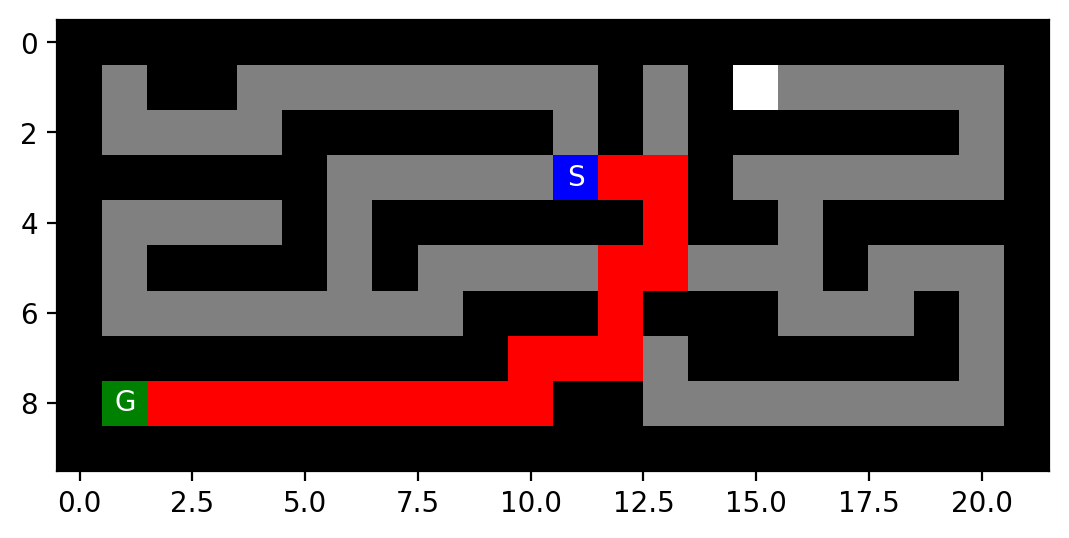


[small_maze.txt] DFS — Detailed Steps
  Start at (np.int64(3), np.int64(11))
  Step 1:     E -> (np.int64(3), np.int64(12))
  Step 2:     E -> (np.int64(3), np.int64(13))
  Step 3:     S -> (np.int64(4), np.int64(13))
  Step 4:     S -> (np.int64(5), np.int64(13))
  Step 5:     E -> (np.int64(5), np.int64(14))
  Step 6:     E -> (np.int64(5), np.int64(15))
  Step 7:     E -> (np.int64(5), np.int64(16))
  Step 8:     S -> (np.int64(6), np.int64(16))
  Step 9:     E -> (np.int64(6), np.int64(17))
  Step 10:     E -> (np.int64(6), np.int64(18))
  Step 11:     N -> (np.int64(5), np.int64(18))
  Step 12:     E -> (np.int64(5), np.int64(19))
  Step 13:     E -> (np.int64(5), np.int64(20))
  Step 14:     S -> (np.int64(6), np.int64(20))
  Step 15:     S -> (np.int64(7), np.int64(20))
  Step 16:     S -> (np.int64(8), np.int64(20))
  Step 17:     W -> (np.int64(8), np.int64(19))
  Step 18:     W -> (np.int64(8), np.int64(18))
  Step 19:     W -> (np.int64(8), np.int64(17))
  Step 20:     W ->

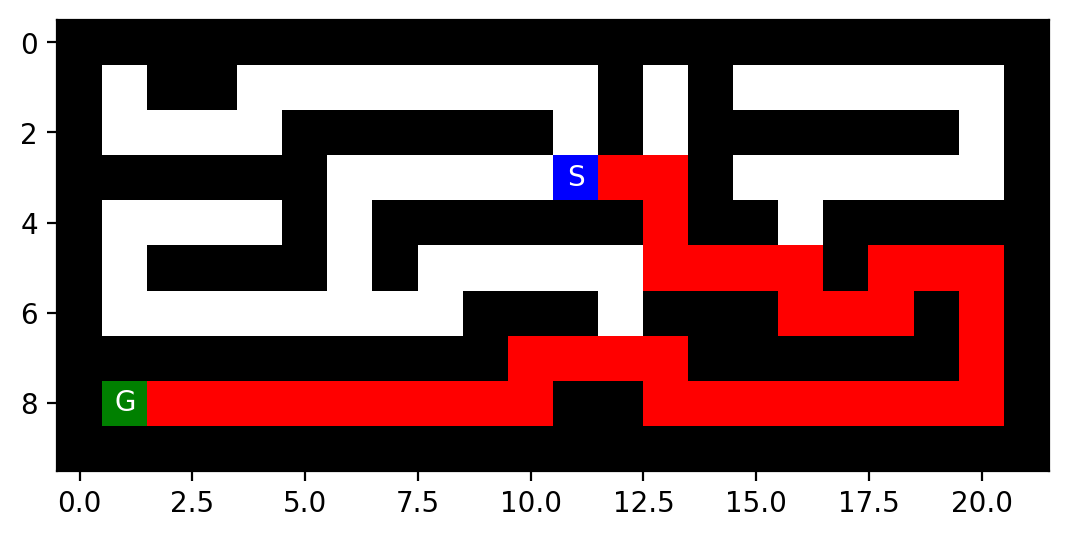


[medium_maze.txt] BFS — Detailed Steps
  Start at (np.int64(1), np.int64(34))
  Step 1:     W -> (np.int64(1), np.int64(33))
  Step 2:     W -> (np.int64(1), np.int64(32))
  Step 3:     W -> (np.int64(1), np.int64(31))
  Step 4:     W -> (np.int64(1), np.int64(30))
  Step 5:     W -> (np.int64(1), np.int64(29))
  Step 6:     W -> (np.int64(1), np.int64(28))
  Step 7:     W -> (np.int64(1), np.int64(27))
  Step 8:     W -> (np.int64(1), np.int64(26))
  Step 9:     W -> (np.int64(1), np.int64(25))
  Step 10:     S -> (np.int64(2), np.int64(25))
  Step 11:     S -> (np.int64(3), np.int64(25))
  Step 12:     E -> (np.int64(3), np.int64(26))
  Step 13:     E -> (np.int64(3), np.int64(27))
  Step 14:     S -> (np.int64(4), np.int64(27))
  Step 15:     S -> (np.int64(5), np.int64(27))
  Step 16:     S -> (np.int64(6), np.int64(27))
  Step 17:     W -> (np.int64(6), np.int64(26))
  Step 18:     W -> (np.int64(6), np.int64(25))
  Step 19:     W -> (np.int64(6), np.int64(24))
  Step 20:     N -

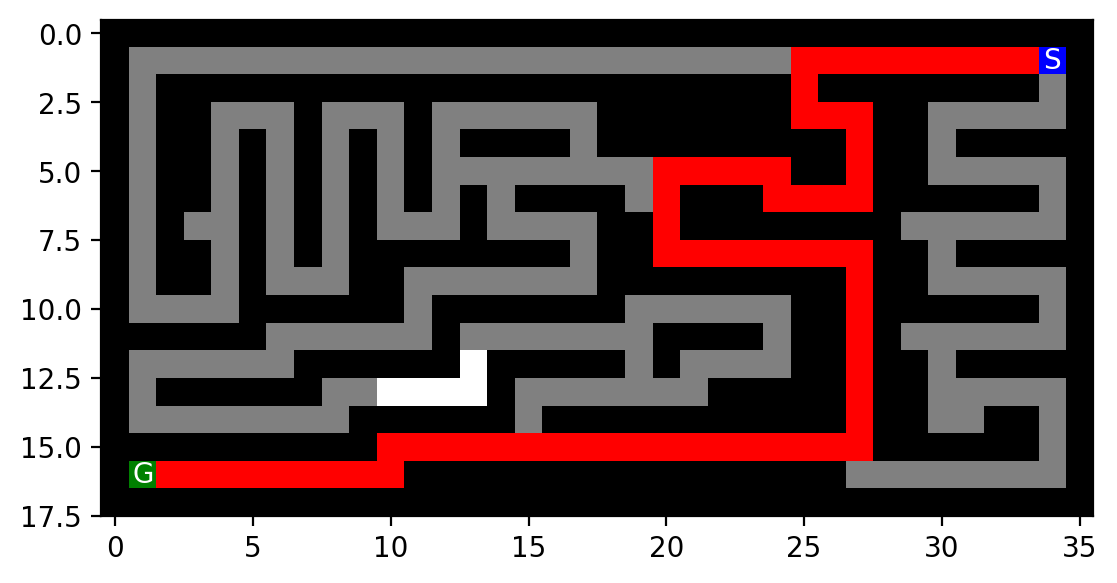


[medium_maze.txt] DFS — Detailed Steps
  Start at (np.int64(1), np.int64(34))
  Step 1:     S -> (np.int64(2), np.int64(34))
  Step 2:     S -> (np.int64(3), np.int64(34))
  Step 3:     W -> (np.int64(3), np.int64(33))
  Step 4:     W -> (np.int64(3), np.int64(32))
  Step 5:     W -> (np.int64(3), np.int64(31))
  Step 6:     W -> (np.int64(3), np.int64(30))
  Step 7:     S -> (np.int64(4), np.int64(30))
  Step 8:     S -> (np.int64(5), np.int64(30))
  Step 9:     E -> (np.int64(5), np.int64(31))
  Step 10:     E -> (np.int64(5), np.int64(32))
  Step 11:     E -> (np.int64(5), np.int64(33))
  Step 12:     E -> (np.int64(5), np.int64(34))
  Step 13:     S -> (np.int64(6), np.int64(34))
  Step 14:     S -> (np.int64(7), np.int64(34))
  Step 15:     W -> (np.int64(7), np.int64(33))
  Step 16:     W -> (np.int64(7), np.int64(32))
  Step 17:     W -> (np.int64(7), np.int64(31))
  Step 18:     W -> (np.int64(7), np.int64(30))
  Step 19:     S -> (np.int64(8), np.int64(30))
  Step 20:     S -

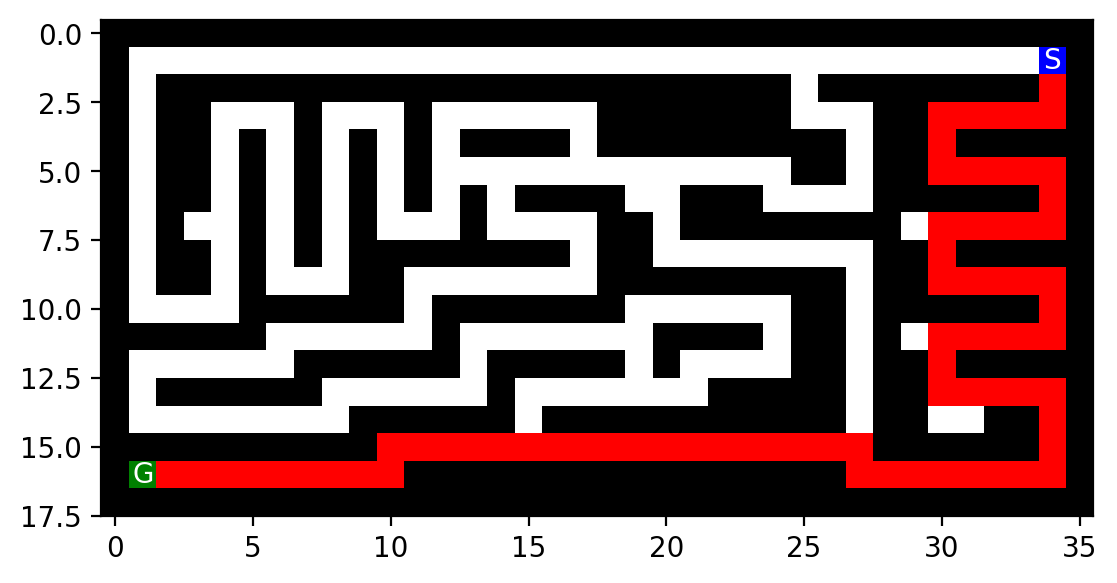


[large_maze.txt] BFS — Detailed Steps
  Start at (np.int64(35), np.int64(35))
  Step 1:     N -> (np.int64(34), np.int64(35))
  Step 2:     N -> (np.int64(33), np.int64(35))
  Step 3:     W -> (np.int64(33), np.int64(34))
  Step 4:     W -> (np.int64(33), np.int64(33))
  Step 5:     W -> (np.int64(33), np.int64(32))
  Step 6:     W -> (np.int64(33), np.int64(31))
  Step 7:     N -> (np.int64(32), np.int64(31))
  Step 8:     N -> (np.int64(31), np.int64(31))
  Step 9:     W -> (np.int64(31), np.int64(30))
  Step 10:     W -> (np.int64(31), np.int64(29))
  Step 11:     S -> (np.int64(32), np.int64(29))
  Step 12:     S -> (np.int64(33), np.int64(29))
  Step 13:     W -> (np.int64(33), np.int64(28))
  Step 14:     W -> (np.int64(33), np.int64(27))
  Step 15:     W -> (np.int64(33), np.int64(26))
  Step 16:     W -> (np.int64(33), np.int64(25))
  Step 17:     W -> (np.int64(33), np.int64(24))
  Step 18:     W -> (np.int64(33), np.int64(23))
  Step 19:     W -> (np.int64(33), np.int64(22))

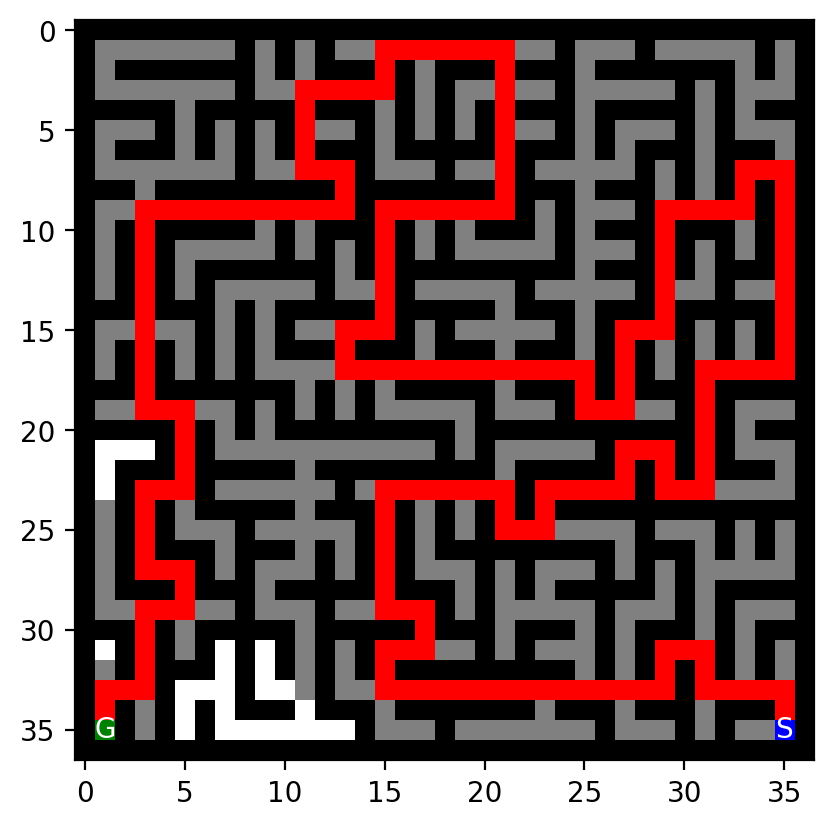


[large_maze.txt] DFS — Detailed Steps
  Start at (np.int64(35), np.int64(35))
  Step 1:     N -> (np.int64(34), np.int64(35))
  Step 2:     N -> (np.int64(33), np.int64(35))
  Step 3:     W -> (np.int64(33), np.int64(34))
  Step 4:     W -> (np.int64(33), np.int64(33))
  Step 5:     W -> (np.int64(33), np.int64(32))
  Step 6:     W -> (np.int64(33), np.int64(31))
  Step 7:     N -> (np.int64(32), np.int64(31))
  Step 8:     N -> (np.int64(31), np.int64(31))
  Step 9:     W -> (np.int64(31), np.int64(30))
  Step 10:     W -> (np.int64(31), np.int64(29))
  Step 11:     S -> (np.int64(32), np.int64(29))
  Step 12:     S -> (np.int64(33), np.int64(29))
  Step 13:     W -> (np.int64(33), np.int64(28))
  Step 14:     W -> (np.int64(33), np.int64(27))
  Step 15:     W -> (np.int64(33), np.int64(26))
  Step 16:     W -> (np.int64(33), np.int64(25))
  Step 17:     W -> (np.int64(33), np.int64(24))
  Step 18:     W -> (np.int64(33), np.int64(23))
  Step 19:     W -> (np.int64(33), np.int64(22))

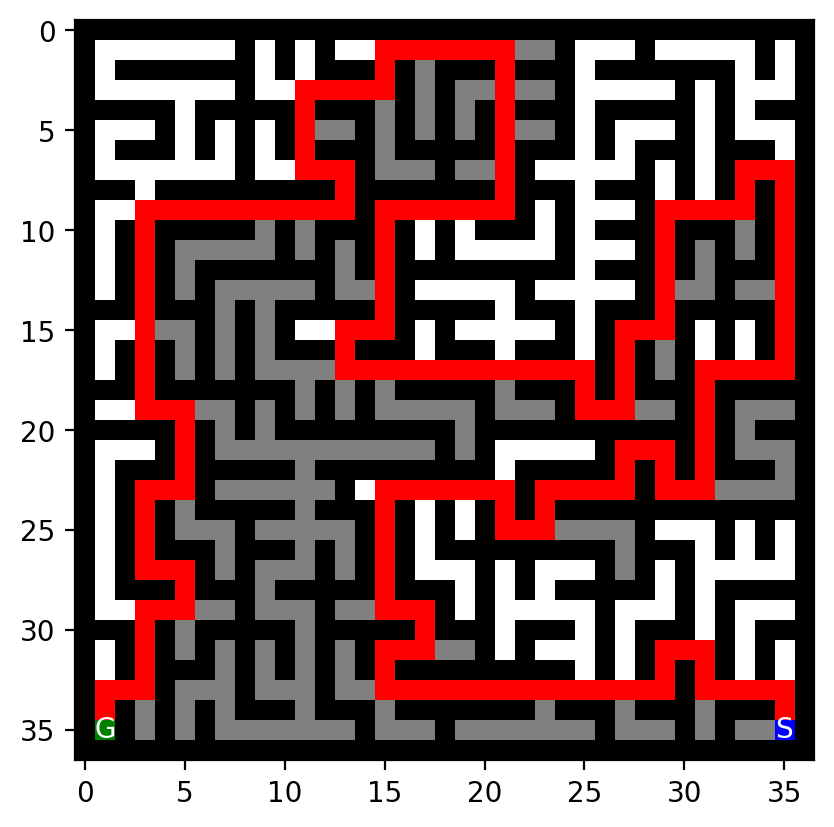


[open_maze.txt] BFS — Detailed Steps
  Start at (np.int64(1), np.int64(35))
  Step 1:     S -> (np.int64(2), np.int64(35))
  Step 2:     S -> (np.int64(3), np.int64(35))
  Step 3:     S -> (np.int64(4), np.int64(35))
  Step 4:     S -> (np.int64(5), np.int64(35))
  Step 5:     S -> (np.int64(6), np.int64(35))
  Step 6:     W -> (np.int64(6), np.int64(34))
  Step 7:     W -> (np.int64(6), np.int64(33))
  Step 8:     W -> (np.int64(6), np.int64(32))
  Step 9:     W -> (np.int64(6), np.int64(31))
  Step 10:     W -> (np.int64(6), np.int64(30))
  Step 11:     W -> (np.int64(6), np.int64(29))
  Step 12:     W -> (np.int64(6), np.int64(28))
  Step 13:     W -> (np.int64(6), np.int64(27))
  Step 14:     W -> (np.int64(6), np.int64(26))
  Step 15:     W -> (np.int64(6), np.int64(25))
  Step 16:     W -> (np.int64(6), np.int64(24))
  Step 17:     W -> (np.int64(6), np.int64(23))
  Step 18:     W -> (np.int64(6), np.int64(22))
  Step 19:     W -> (np.int64(6), np.int64(21))
  Step 20:     W -> 

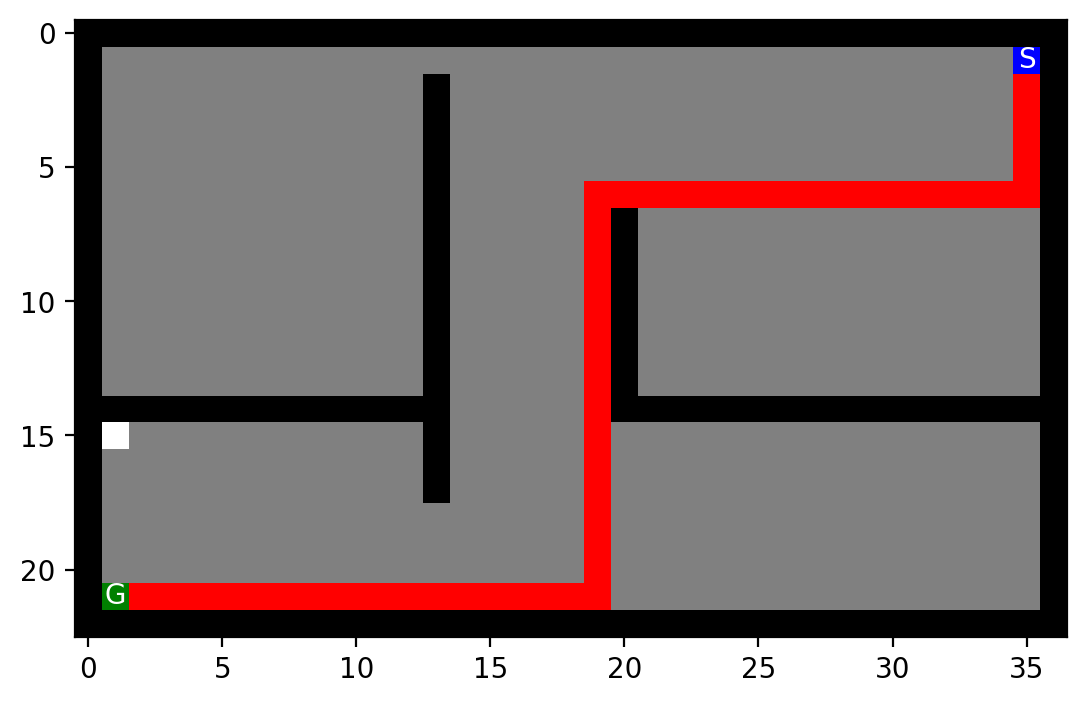


[open_maze.txt] DFS — Detailed Steps
  Start at (np.int64(1), np.int64(35))
  Step 1:     S -> (np.int64(2), np.int64(35))
  Step 2:     S -> (np.int64(3), np.int64(35))
  Step 3:     S -> (np.int64(4), np.int64(35))
  Step 4:     S -> (np.int64(5), np.int64(35))
  Step 5:     S -> (np.int64(6), np.int64(35))
  Step 6:     S -> (np.int64(7), np.int64(35))
  Step 7:     S -> (np.int64(8), np.int64(35))
  Step 8:     S -> (np.int64(9), np.int64(35))
  Step 9:     S -> (np.int64(10), np.int64(35))
  Step 10:     S -> (np.int64(11), np.int64(35))
  Step 11:     S -> (np.int64(12), np.int64(35))
  Step 12:     S -> (np.int64(13), np.int64(35))
  Step 13:     W -> (np.int64(13), np.int64(34))
  Step 14:     W -> (np.int64(13), np.int64(33))
  Step 15:     W -> (np.int64(13), np.int64(32))
  Step 16:     W -> (np.int64(13), np.int64(31))
  Step 17:     W -> (np.int64(13), np.int64(30))
  Step 18:     W -> (np.int64(13), np.int64(29))
  Step 19:     W -> (np.int64(13), np.int64(28))
  Step 20

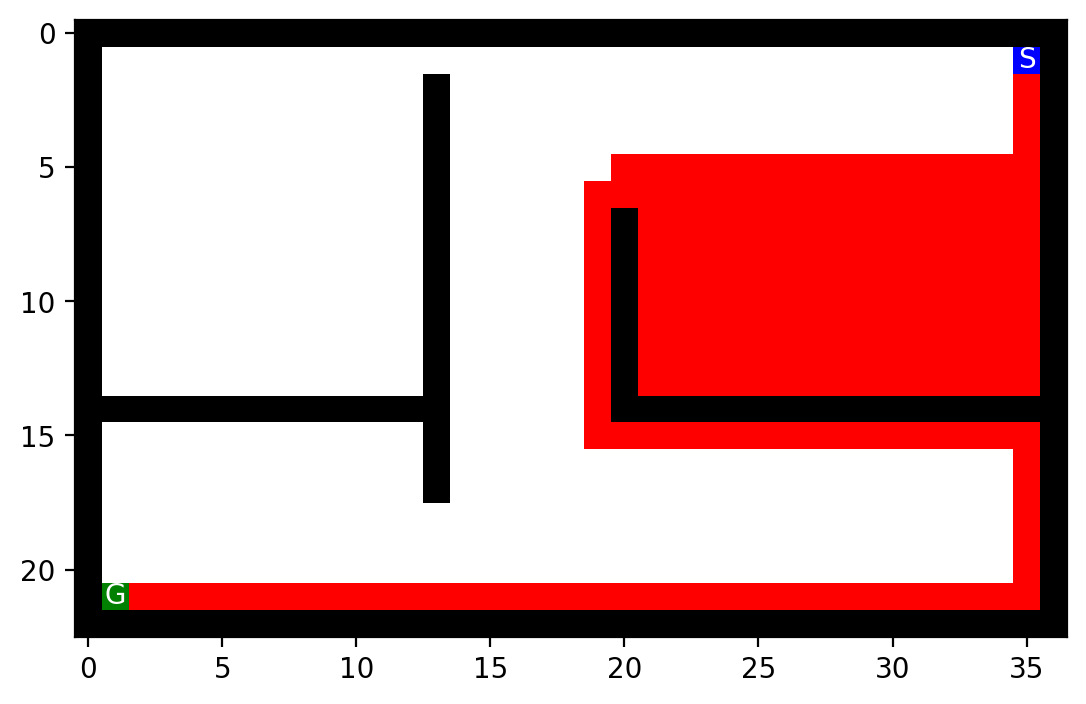


[L_maze.txt] BFS — Detailed Steps
  Start at (np.int64(9), np.int64(5))
  Step 1:     E -> (np.int64(9), np.int64(6))
  Step 2:     E -> (np.int64(9), np.int64(7))
  Step 3:     E -> (np.int64(9), np.int64(8))
  Step 4:     E -> (np.int64(9), np.int64(9))
  Step 5:     S -> (np.int64(10), np.int64(9))
  Step 6:     E -> (np.int64(10), np.int64(10))
  Step 7:     E -> (np.int64(10), np.int64(11))
  Step 8:     E -> (np.int64(10), np.int64(12))
  Step 9:     N -> (np.int64(9), np.int64(12))
  Step 10:     N -> (np.int64(8), np.int64(12))
  Step 11:     N -> (np.int64(7), np.int64(12))
  Step 12:     N -> (np.int64(6), np.int64(12))
  Step 13:     N -> (np.int64(5), np.int64(12))
  Step 14:     N -> (np.int64(4), np.int64(12))
  Step 15:     N -> (np.int64(3), np.int64(12))
  Step 16:     N -> (np.int64(2), np.int64(12))
  Goal at (np.int64(2), np.int64(12))
  Total path cost: 16



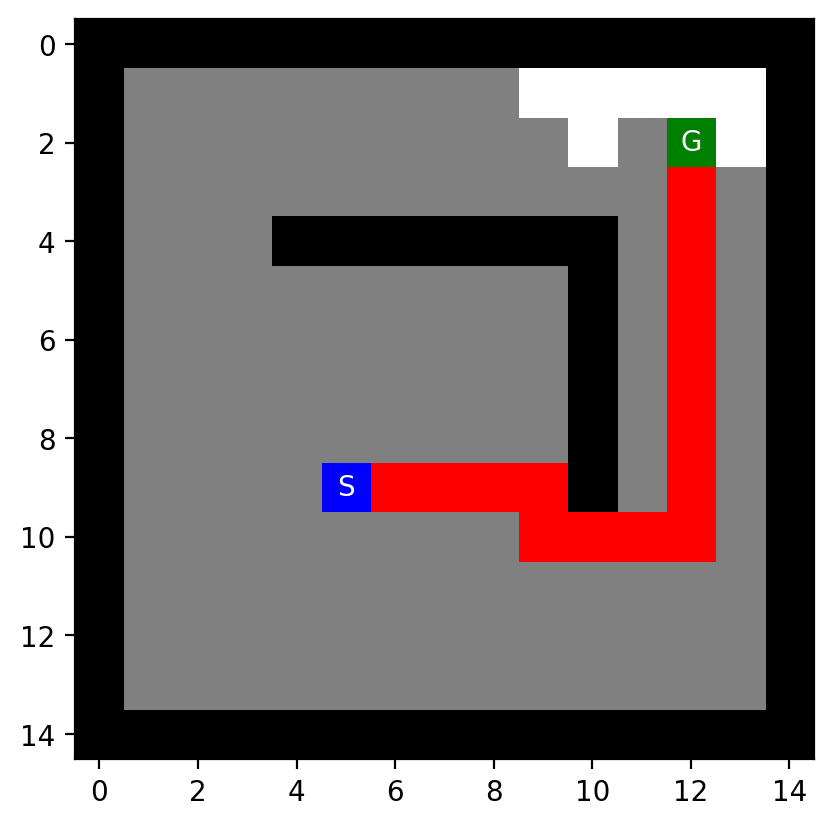


[L_maze.txt] DFS — Detailed Steps
  Start at (np.int64(9), np.int64(5))
  Step 1:     E -> (np.int64(9), np.int64(6))
  Step 2:     E -> (np.int64(9), np.int64(7))
  Step 3:     E -> (np.int64(9), np.int64(8))
  Step 4:     E -> (np.int64(9), np.int64(9))
  Step 5:     S -> (np.int64(10), np.int64(9))
  Step 6:     E -> (np.int64(10), np.int64(10))
  Step 7:     E -> (np.int64(10), np.int64(11))
  Step 8:     E -> (np.int64(10), np.int64(12))
  Step 9:     E -> (np.int64(10), np.int64(13))
  Step 10:     S -> (np.int64(11), np.int64(13))
  Step 11:     S -> (np.int64(12), np.int64(13))
  Step 12:     S -> (np.int64(13), np.int64(13))
  Step 13:     W -> (np.int64(13), np.int64(12))
  Step 14:     W -> (np.int64(13), np.int64(11))
  Step 15:     W -> (np.int64(13), np.int64(10))
  Step 16:     W -> (np.int64(13), np.int64(9))
  Step 17:     W -> (np.int64(13), np.int64(8))
  Step 18:     W -> (np.int64(13), np.int64(7))
  Step 19:     W -> (np.int64(13), np.int64(6))
  Step 20:     W -

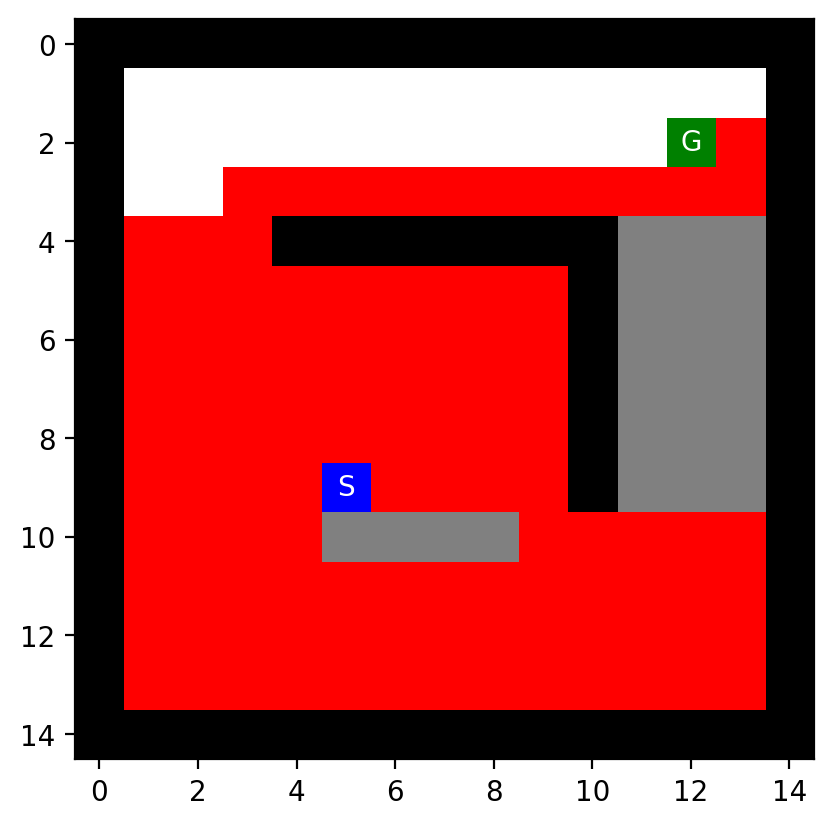


[loops_maze.txt] BFS — Detailed Steps
  Start at (np.int64(10), np.int64(1))
  Step 1:     E -> (np.int64(10), np.int64(2))
  Step 2:     E -> (np.int64(10), np.int64(3))
  Step 3:     E -> (np.int64(10), np.int64(4))
  Step 4:     E -> (np.int64(10), np.int64(5))
  Step 5:     E -> (np.int64(10), np.int64(6))
  Step 6:     E -> (np.int64(10), np.int64(7))
  Step 7:     E -> (np.int64(10), np.int64(8))
  Step 8:     N -> (np.int64(9), np.int64(8))
  Step 9:     N -> (np.int64(8), np.int64(8))
  Step 10:     N -> (np.int64(7), np.int64(8))
  Step 11:     N -> (np.int64(6), np.int64(8))
  Step 12:     N -> (np.int64(5), np.int64(8))
  Step 13:     N -> (np.int64(4), np.int64(8))
  Step 14:     N -> (np.int64(3), np.int64(8))
  Step 15:     N -> (np.int64(2), np.int64(8))
  Step 16:     W -> (np.int64(2), np.int64(7))
  Step 17:     W -> (np.int64(2), np.int64(6))
  Step 18:     W -> (np.int64(2), np.int64(5))
  Step 19:     W -> (np.int64(2), np.int64(4))
  Step 20:     W -> (np.int64(2

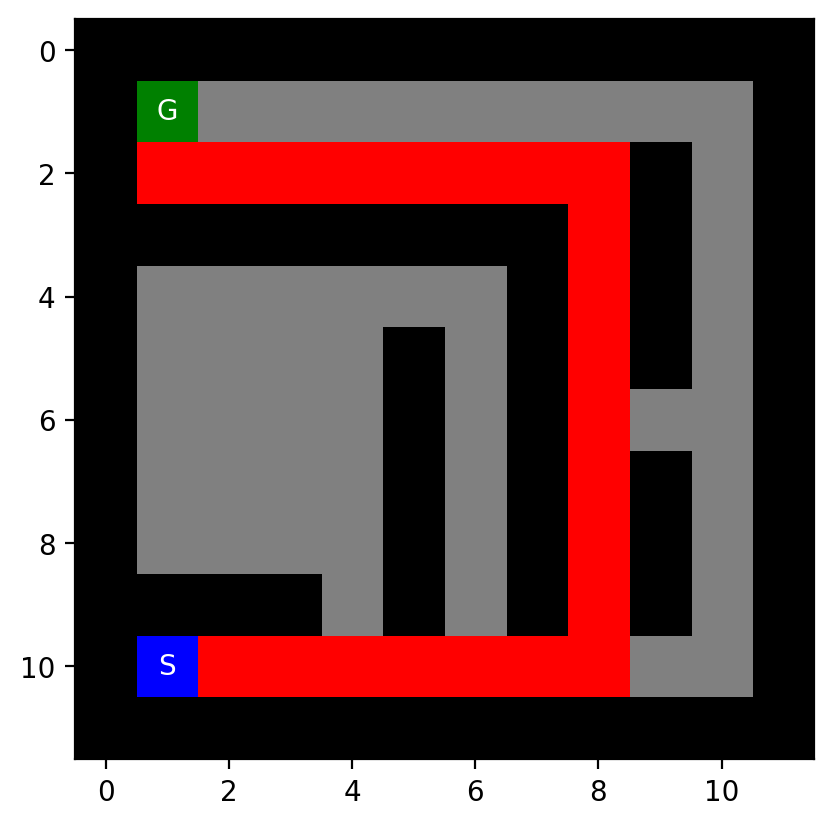


[loops_maze.txt] DFS — Detailed Steps
  Start at (np.int64(10), np.int64(1))
  Step 1:     E -> (np.int64(10), np.int64(2))
  Step 2:     E -> (np.int64(10), np.int64(3))
  Step 3:     E -> (np.int64(10), np.int64(4))
  Step 4:     E -> (np.int64(10), np.int64(5))
  Step 5:     E -> (np.int64(10), np.int64(6))
  Step 6:     E -> (np.int64(10), np.int64(7))
  Step 7:     E -> (np.int64(10), np.int64(8))
  Step 8:     E -> (np.int64(10), np.int64(9))
  Step 9:     E -> (np.int64(10), np.int64(10))
  Step 10:     N -> (np.int64(9), np.int64(10))
  Step 11:     N -> (np.int64(8), np.int64(10))
  Step 12:     N -> (np.int64(7), np.int64(10))
  Step 13:     N -> (np.int64(6), np.int64(10))
  Step 14:     W -> (np.int64(6), np.int64(9))
  Step 15:     W -> (np.int64(6), np.int64(8))
  Step 16:     N -> (np.int64(5), np.int64(8))
  Step 17:     N -> (np.int64(4), np.int64(8))
  Step 18:     N -> (np.int64(3), np.int64(8))
  Step 19:     N -> (np.int64(2), np.int64(8))
  Step 20:     W -> (np.

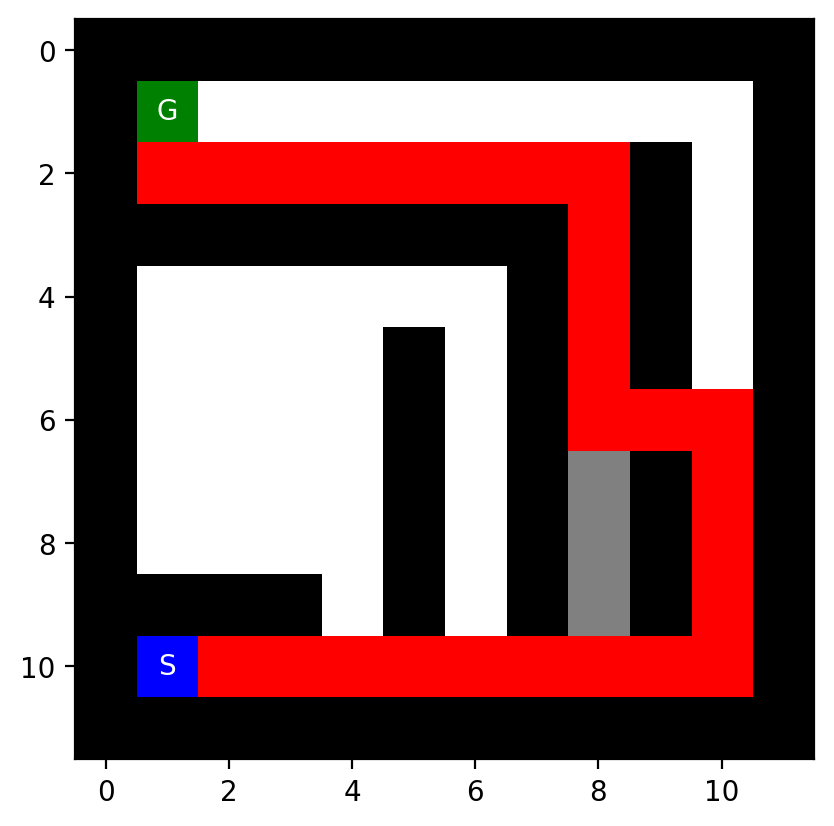


[empty_maze.txt] BFS — Detailed Steps
  Start at (np.int64(9), np.int64(2))
  Step 1:     E -> (np.int64(9), np.int64(3))
  Step 2:     E -> (np.int64(9), np.int64(4))
  Step 3:     E -> (np.int64(9), np.int64(5))
  Step 4:     E -> (np.int64(9), np.int64(6))
  Step 5:     E -> (np.int64(9), np.int64(7))
  Step 6:     E -> (np.int64(9), np.int64(8))
  Step 7:     E -> (np.int64(9), np.int64(9))
  Step 8:     N -> (np.int64(8), np.int64(9))
  Step 9:     N -> (np.int64(7), np.int64(9))
  Step 10:     N -> (np.int64(6), np.int64(9))
  Step 11:     N -> (np.int64(5), np.int64(9))
  Step 12:     N -> (np.int64(4), np.int64(9))
  Step 13:     N -> (np.int64(3), np.int64(9))
  Step 14:     N -> (np.int64(2), np.int64(9))
  Goal at (np.int64(2), np.int64(9))
  Total path cost: 14



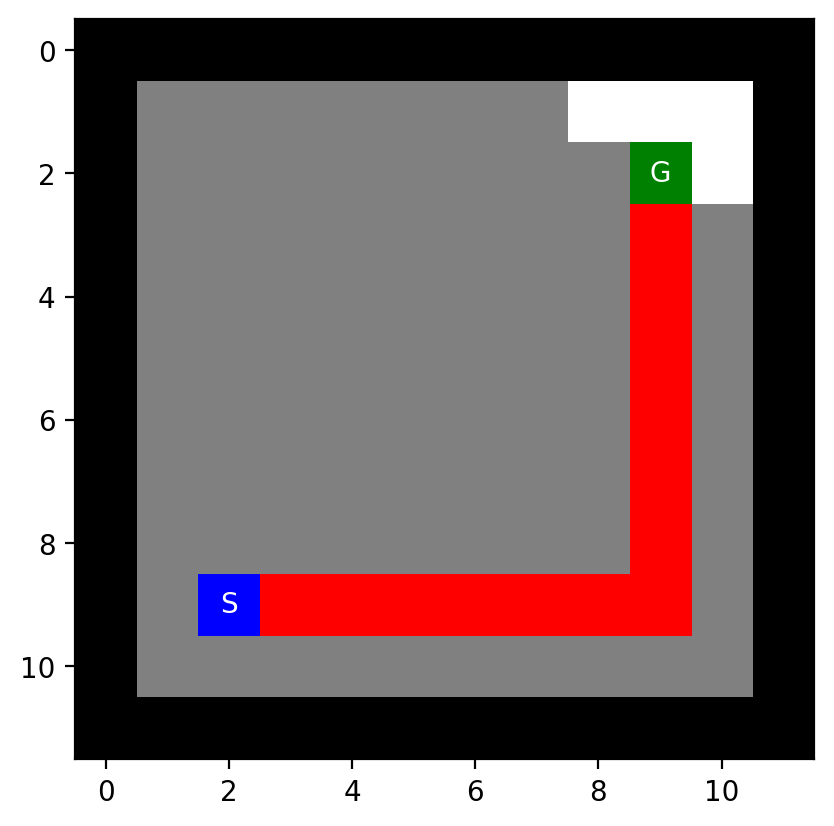


[empty_maze.txt] DFS — Detailed Steps
  Start at (np.int64(9), np.int64(2))
  Step 1:     E -> (np.int64(9), np.int64(3))
  Step 2:     E -> (np.int64(9), np.int64(4))
  Step 3:     E -> (np.int64(9), np.int64(5))
  Step 4:     E -> (np.int64(9), np.int64(6))
  Step 5:     E -> (np.int64(9), np.int64(7))
  Step 6:     E -> (np.int64(9), np.int64(8))
  Step 7:     E -> (np.int64(9), np.int64(9))
  Step 8:     E -> (np.int64(9), np.int64(10))
  Step 9:     S -> (np.int64(10), np.int64(10))
  Step 10:     W -> (np.int64(10), np.int64(9))
  Step 11:     W -> (np.int64(10), np.int64(8))
  Step 12:     W -> (np.int64(10), np.int64(7))
  Step 13:     W -> (np.int64(10), np.int64(6))
  Step 14:     W -> (np.int64(10), np.int64(5))
  Step 15:     W -> (np.int64(10), np.int64(4))
  Step 16:     W -> (np.int64(10), np.int64(3))
  Step 17:     W -> (np.int64(10), np.int64(2))
  Step 18:     W -> (np.int64(10), np.int64(1))
  Step 19:     N -> (np.int64(9), np.int64(1))
  Step 20:     N -> (np.int

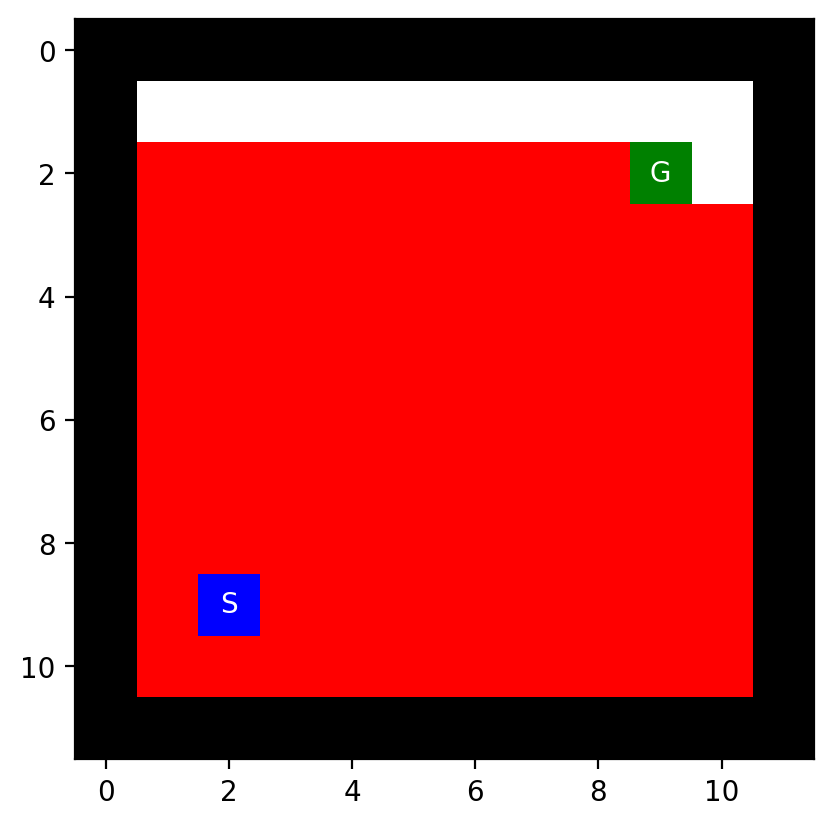


[empty_maze_2.txt] BFS — Detailed Steps
  Start at (np.int64(2), np.int64(9))
  Step 1:     S -> (np.int64(3), np.int64(9))
  Step 2:     S -> (np.int64(4), np.int64(9))
  Step 3:     S -> (np.int64(5), np.int64(9))
  Step 4:     S -> (np.int64(6), np.int64(9))
  Step 5:     S -> (np.int64(7), np.int64(9))
  Step 6:     S -> (np.int64(8), np.int64(9))
  Step 7:     S -> (np.int64(9), np.int64(9))
  Step 8:     W -> (np.int64(9), np.int64(8))
  Step 9:     W -> (np.int64(9), np.int64(7))
  Step 10:     W -> (np.int64(9), np.int64(6))
  Step 11:     W -> (np.int64(9), np.int64(5))
  Step 12:     W -> (np.int64(9), np.int64(4))
  Step 13:     W -> (np.int64(9), np.int64(3))
  Step 14:     W -> (np.int64(9), np.int64(2))
  Goal at (np.int64(9), np.int64(2))
  Total path cost: 14



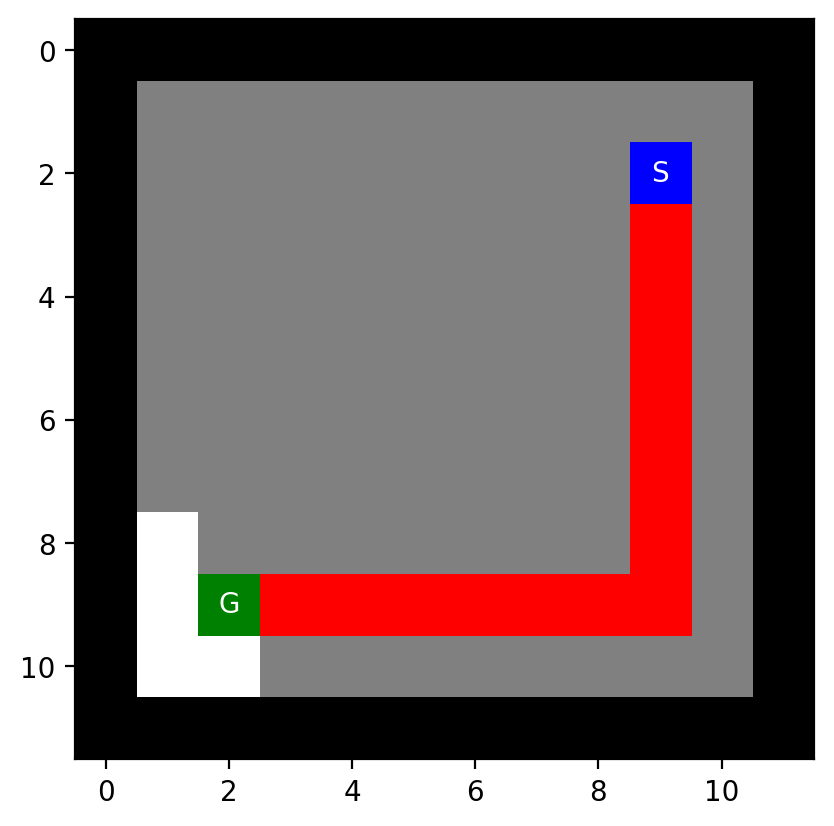


[empty_maze_2.txt] DFS — Detailed Steps
  Start at (np.int64(2), np.int64(9))
  Step 1:     E -> (np.int64(2), np.int64(10))
  Step 2:     S -> (np.int64(3), np.int64(10))
  Step 3:     S -> (np.int64(4), np.int64(10))
  Step 4:     S -> (np.int64(5), np.int64(10))
  Step 5:     S -> (np.int64(6), np.int64(10))
  Step 6:     S -> (np.int64(7), np.int64(10))
  Step 7:     S -> (np.int64(8), np.int64(10))
  Step 8:     S -> (np.int64(9), np.int64(10))
  Step 9:     S -> (np.int64(10), np.int64(10))
  Step 10:     W -> (np.int64(10), np.int64(9))
  Step 11:     W -> (np.int64(10), np.int64(8))
  Step 12:     W -> (np.int64(10), np.int64(7))
  Step 13:     W -> (np.int64(10), np.int64(6))
  Step 14:     W -> (np.int64(10), np.int64(5))
  Step 15:     W -> (np.int64(10), np.int64(4))
  Step 16:     W -> (np.int64(10), np.int64(3))
  Step 17:     W -> (np.int64(10), np.int64(2))
  Step 18:     W -> (np.int64(10), np.int64(1))
  Step 19:     N -> (np.int64(9), np.int64(1))
  Step 20:     E -

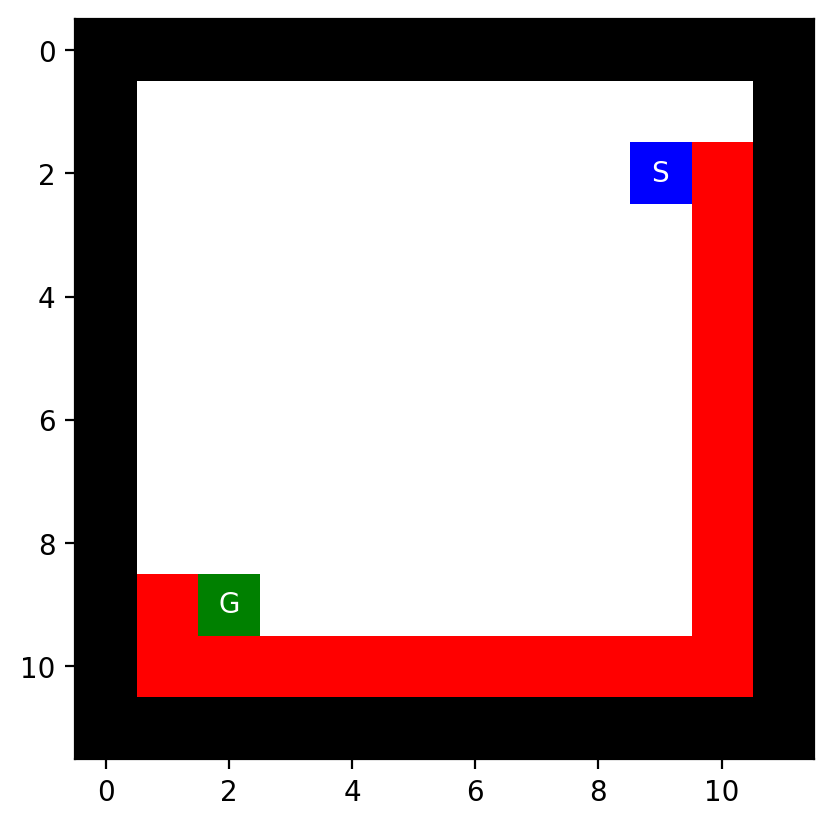


=== Search Results ===
            Maze Algorithm  Path Cost  Nodes Expanded  Max Frontier Size  Max Depth Reached
  small_maze.txt       BFS         19              93                  9                 19
  small_maze.txt       DFS         37              37                 38                 36
 medium_maze.txt       BFS         68             269                  9                 68
 medium_maze.txt       DFS         74              74                 75                 73
  large_maze.txt       BFS        210             621                  8                210
  large_maze.txt       DFS        210             417                223                222
   open_maze.txt       BFS         54             683                 25                 54
   open_maze.txt       DFS        206             206                207                205
      L_maze.txt       BFS         16             150                 17                 16
      L_maze.txt       DFS        108            4149   

In [15]:
import numpy as np
import pandas as pd
from collections import deque
import maze_helper as mh

# Action order chosen to match the "EAST-first" style seen in your friend's output
# (This affects which valid solution BFS/DFS returns.)
DIRS = [
    ("E", (0, 1)),
    ("S", (1, 0)),
    ("W", (0, -1)),
    ("N", (-1, 0)),
]

def in_bounds(maze, p):
    r, c = p
    return 0 <= r < maze.shape[0] and 0 <= c < maze.shape[1]

def is_open(maze, p):
    return mh.look(maze, p) != "X"

def succ(maze, p):
    r, c = p
    for a, (dr, dc) in DIRS:
        q = (r + dr, c + dc)
        if in_bounds(maze, q) and is_open(maze, q):
            yield a, q

class Node:
    def __init__(self, pos, parent=None, action=None, depth=0):
        self.pos = tuple(pos)
        self.parent = parent
        self.action = action
        self.depth = depth

        # DFS bookkeeping (for memory release + iterative backtracking)
        self._expanded = False
        self._next_i = 0

    def path_nodes(self):
        cur = self
        out = []
        while cur is not None:
            out.append(cur)
            cur = cur.parent
        out.reverse()
        return out

def actions_from_goal(goal_node):
    nodes = goal_node.path_nodes()
    return [n.action for n in nodes[1:]]

def positions_from_goal(goal_node):
    return [n.pos for n in goal_node.path_nodes()]

def print_steps(maze_name, alg_name, start, goal, actions, positions):
    # EXACT console style like your friend’s sample
    print(f"\n[{maze_name}] {alg_name} — Detailed Steps")
    if actions is None or positions is None:
        print("  Goal not found.")
        return
    print(f"  Start at {start}")
    for i, (a, p) in enumerate(zip(actions, positions[1:]), start=1):
        print(f"  Step {i}: {a.upper():>5} -> {p}")
    print(f"  Goal at {goal}")
    print(f"  Total path cost: {len(actions)}")
    print("")  # blank line like the sample

def draw_solution(maze, expanded, goal_node):
    """
    Display a COPY of maze:
      '.' = expanded (visited)
      'P' = final path
    Search itself never writes to maze (complies with the notes). :contentReference[oaicite:2]{index=2}
    """
    M = np.copy(maze)
    s = mh.find_pos(M, what="S")
    g = mh.find_pos(M, what="G")

    for p in expanded:
        if p != s and p != g and M[p] == " ":
            M[p] = "."

    if goal_node is not None:
        for p in positions_from_goal(goal_node):
            if p != s and p != g and M[p] in [" ", "."]:
                M[p] = "P"

    M[s] = "S"
    M[g] = "G"
    mh.show_maze(M)

def bfs_search(maze, start, goal):
    root = Node(start)
    frontier = deque([root])
    reached = {root.pos}
    expanded = set()

    nodes_expanded = 0
    max_depth = 0
    max_frontier = len(frontier)

    while frontier:
        if len(frontier) > max_frontier:
            max_frontier = len(frontier)

        node = frontier.popleft()
        nodes_expanded += 1
        expanded.add(node.pos)
        if node.depth > max_depth:
            max_depth = node.depth

        if node.pos == goal:
            return {
                "goal_node": node,
                "plan": actions_from_goal(node),
                "path_cost": node.depth,
                "nodes_expanded": nodes_expanded,
                "max_tree_depth": max_depth,
                "max_frontier": max_frontier,
                "expanded": expanded,
            }

        for a, q in succ(maze, node.pos):
            if q not in reached:
                reached.add(q)
                frontier.append(Node(q, node, a, node.depth + 1))

    return {
        "goal_node": None,
        "plan": None,
        "path_cost": None,
        "nodes_expanded": nodes_expanded,
        "max_tree_depth": max_depth,
        "max_frontier": max_frontier,
        "expanded": expanded,
    }

def dfs_search(maze, start, goal):
    """
    Proper DFS:
      - NO reached set
      - cycle checking only on current path
      - memory released by popping stack when backtracking :contentReference[oaicite:3]{index=3}
    """
    root = Node(start)
    stack = [root]
    on_path = {root.pos}
    expanded = set()

    nodes_expanded = 0
    max_depth = 0
    max_frontier = len(stack)

    while stack:
        if len(stack) > max_frontier:
            max_frontier = len(stack)

        node = stack[-1]

        if node.pos == goal:
            return {
                "goal_node": node,
                "plan": actions_from_goal(node),
                "path_cost": node.depth,
                "nodes_expanded": nodes_expanded,
                "max_tree_depth": max_depth,
                "max_frontier": max_frontier,
                "expanded": expanded,
            }

        if not node._expanded:
            node._expanded = True
            nodes_expanded += 1
            expanded.add(node.pos)
            if node.depth > max_depth:
                max_depth = node.depth

        if node._next_i >= len(DIRS):
            stack.pop()
            on_path.remove(node.pos)
            continue

        a, (dr, dc) = DIRS[node._next_i]
        node._next_i += 1
        q = (node.pos[0] + dr, node.pos[1] + dc)

        if not (in_bounds(maze, q) and is_open(maze, q)):
            continue
        if q in on_path:
            continue

        child = Node(q, node, a, node.depth + 1)
        stack.append(child)
        on_path.add(q)

    return {
        "goal_node": None,
        "plan": None,
        "path_cost": None,
        "nodes_expanded": nodes_expanded,
        "max_tree_depth": max_depth,
        "max_frontier": max_frontier,
        "expanded": expanded,
    }

def run_all_task2():
    maze_files = [
        "small_maze.txt",
        "medium_maze.txt",
        "large_maze.txt",
        "open_maze.txt",
        "L_maze.txt",
        "loops_maze.txt",
        "empty_maze.txt",
        "empty_maze_2.txt",
    ]

    records = []

    for mf in maze_files:
        with open(mf, "r") as f:
            txt = f.read()

        maze = mh.parse_maze(txt)
        start = mh.find_pos(maze, what="S")
        goal = mh.find_pos(maze, what="G")

        for alg_name, alg_fn in [("BFS", bfs_search), ("DFS", dfs_search)]:
            res = alg_fn(maze, start, goal)
            goal_node = res["goal_node"]

            actions = res["plan"]
            positions = positions_from_goal(goal_node) if goal_node is not None else None

            # 1) Detailed Steps (same format)
            print_steps(mf, alg_name, start, goal, actions, positions)

            # 2) Display marked maze (visited + path)
            draw_solution(maze, res["expanded"], goal_node)

            # 3) Record for bottom summary table
            records.append({
                "Maze": mf,
                "Algorithm": alg_name,
                "Path Cost": res["path_cost"],
                "Nodes Expanded": res["nodes_expanded"],
                "Max Frontier Size": res["max_frontier"],
                "Max Depth Reached": res["max_tree_depth"],
            })

    df = pd.DataFrame(records, columns=[
        "Maze", "Algorithm", "Path Cost",
        "Nodes Expanded", "Max Frontier Size", "Max Depth Reached"
    ])

    print("\n=== Search Results ===")
    print(df.to_string(index=False))
    return df

# Run everything
df_task2 = run_all_task2()

How does BFS and DFS (without a reached data structure) deal with loops (cycles)?

In [ ]:
# Discussion

* **Breadth-First Search (BFS)** avoids loops by keeping track of every state it has already discovered using a reached (or visited) set. Once a position has been reached, it is never added to the frontier again. This ensures that BFS does not revisit the same locations and cannot get stuck cycling through the maze.

* **Depth-First Search (DFS)** without a reached set does not remember all previously visited states. Because of this, it cannot block repeated states globally. Instead, it performs cycle checking only on the current search path. The algorithm keeps track of the states that are currently on the stack. If the next move would return to a state already on that path, the move is rejected. This prevents infinite loops, but DFS may still revisit the same state later through a different route.

Are your implementations complete and optimal? Explain why. What is the time and space complexity of each of **your** implementations? Especially discuss the difference in space complexity between BFS and DFS.

In [ ]:
# Discussion


# Discussion: Completeness, optimality, and time/space complexity

**Breadth-First Search (BFS)**

* Completeness: BFS is complete in a finite maze. If a path from the start to the goal exists, BFS is guaranteed to find it because it explores all states level by level and never repeats states.

* Optimality: BFS is optimal for this problem because all actions have equal cost. The first time BFS reaches the goal, it has found the shortest possible path.

* Time complexity: In the worst case, BFS explores all reachable states and transitions, which can be described as
O(b^
d
), where
b is the branching factor and
d is the depth of the optimal solution.

* Space complexity: BFS has high memory usage because it must store the entire frontier and the reached set. Its space complexity is also
O(b^
d
).

**Depth-First Search (DFS) without reached**

* Completeness: With cycle checking and a finite maze, DFS will eventually terminate and can find a solution if one exists. However, it may take much longer than BFS because it can revisit the same states through different paths.

* Optimality: DFS is not optimal. It may find a solution that is far from the shortest path, since it explores deeply along one branch before considering others.

* Time complexity: In the worst case, DFS can explore very deep paths, leading to a time complexity of
O(b^
m
), where
m is the maximum depth of the search.

* Space complexity: DFS is much more memory-efficient than BFS. It mainly stores the current path and a small amount of bookkeeping information, giving it a space complexity of
O(m).

**Key difference in space usage**

The main practical difference between BFS and DFS is memory. BFS can quickly consume large amounts of memory because it keeps many nodes in the frontier at once. DFS, on the other hand, only stores the current path and frees memory when it backtracks, which makes it significantly more space-efficient, especially in large or open mazes.

## Task 3: Informed search: Implement greedy best-first search and A* search  [20 Points]

You can use the map to estimate the distance from your current position to the goal using the Manhattan distance (see https://en.wikipedia.org/wiki/Taxicab_geometry) as a heuristic function. Both algorithms are based on Best-First search which requires only a small change from the BFS algorithm you have already implemented (see textbook/slides).


[small_maze.txt] GBFS — Detailed Steps
  Start at (np.int64(3), np.int64(11))
  Step 1:     W -> (np.int64(3), np.int64(10))
  Step 2:     W -> (np.int64(3), np.int64(9))
  Step 3:     W -> (np.int64(3), np.int64(8))
  Step 4:     W -> (np.int64(3), np.int64(7))
  Step 5:     W -> (np.int64(3), np.int64(6))
  Step 6:     S -> (np.int64(4), np.int64(6))
  Step 7:     S -> (np.int64(5), np.int64(6))
  Step 8:     S -> (np.int64(6), np.int64(6))
  Step 9:     E -> (np.int64(6), np.int64(7))
  Step 10:     E -> (np.int64(6), np.int64(8))
  Step 11:     N -> (np.int64(5), np.int64(8))
  Step 12:     E -> (np.int64(5), np.int64(9))
  Step 13:     E -> (np.int64(5), np.int64(10))
  Step 14:     E -> (np.int64(5), np.int64(11))
  Step 15:     E -> (np.int64(5), np.int64(12))
  Step 16:     S -> (np.int64(6), np.int64(12))
  Step 17:     S -> (np.int64(7), np.int64(12))
  Step 18:     W -> (np.int64(7), np.int64(11))
  Step 19:     W -> (np.int64(7), np.int64(10))
  Step 20:     S -> (np.int64

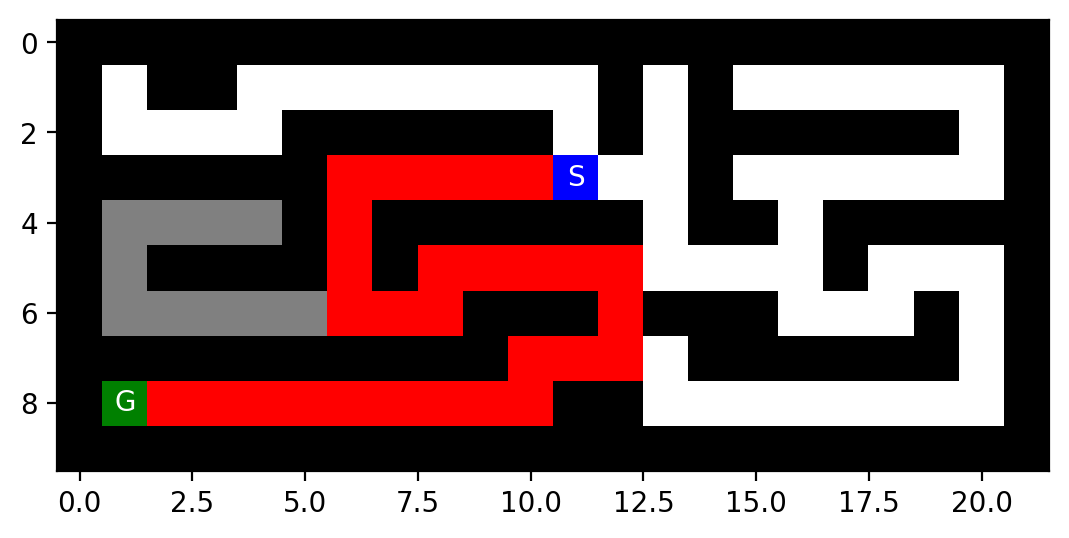


[small_maze.txt] A* — Detailed Steps
  Start at (np.int64(3), np.int64(11))
  Step 1:     E -> (np.int64(3), np.int64(12))
  Step 2:     E -> (np.int64(3), np.int64(13))
  Step 3:     S -> (np.int64(4), np.int64(13))
  Step 4:     S -> (np.int64(5), np.int64(13))
  Step 5:     W -> (np.int64(5), np.int64(12))
  Step 6:     S -> (np.int64(6), np.int64(12))
  Step 7:     S -> (np.int64(7), np.int64(12))
  Step 8:     W -> (np.int64(7), np.int64(11))
  Step 9:     W -> (np.int64(7), np.int64(10))
  Step 10:     S -> (np.int64(8), np.int64(10))
  Step 11:     W -> (np.int64(8), np.int64(9))
  Step 12:     W -> (np.int64(8), np.int64(8))
  Step 13:     W -> (np.int64(8), np.int64(7))
  Step 14:     W -> (np.int64(8), np.int64(6))
  Step 15:     W -> (np.int64(8), np.int64(5))
  Step 16:     W -> (np.int64(8), np.int64(4))
  Step 17:     W -> (np.int64(8), np.int64(3))
  Step 18:     W -> (np.int64(8), np.int64(2))
  Step 19:     W -> (np.int64(8), np.int64(1))
  Goal at (np.int64(8), np.in

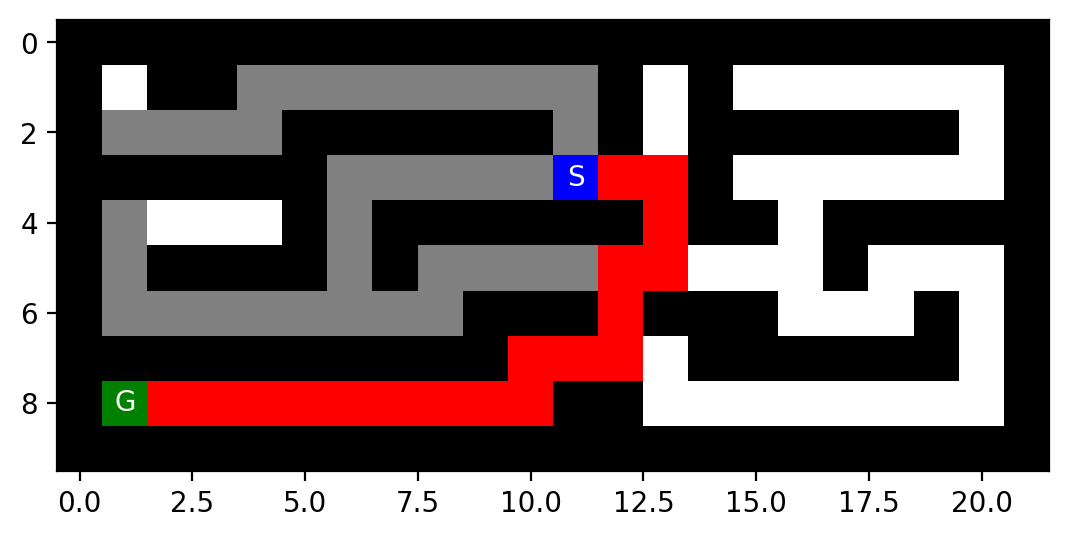


[medium_maze.txt] GBFS — Detailed Steps
  Start at (np.int64(1), np.int64(34))
  Step 1:     S -> (np.int64(2), np.int64(34))
  Step 2:     S -> (np.int64(3), np.int64(34))
  Step 3:     W -> (np.int64(3), np.int64(33))
  Step 4:     W -> (np.int64(3), np.int64(32))
  Step 5:     W -> (np.int64(3), np.int64(31))
  Step 6:     W -> (np.int64(3), np.int64(30))
  Step 7:     S -> (np.int64(4), np.int64(30))
  Step 8:     S -> (np.int64(5), np.int64(30))
  Step 9:     E -> (np.int64(5), np.int64(31))
  Step 10:     E -> (np.int64(5), np.int64(32))
  Step 11:     E -> (np.int64(5), np.int64(33))
  Step 12:     E -> (np.int64(5), np.int64(34))
  Step 13:     S -> (np.int64(6), np.int64(34))
  Step 14:     S -> (np.int64(7), np.int64(34))
  Step 15:     W -> (np.int64(7), np.int64(33))
  Step 16:     W -> (np.int64(7), np.int64(32))
  Step 17:     W -> (np.int64(7), np.int64(31))
  Step 18:     W -> (np.int64(7), np.int64(30))
  Step 19:     S -> (np.int64(8), np.int64(30))
  Step 20:     S 

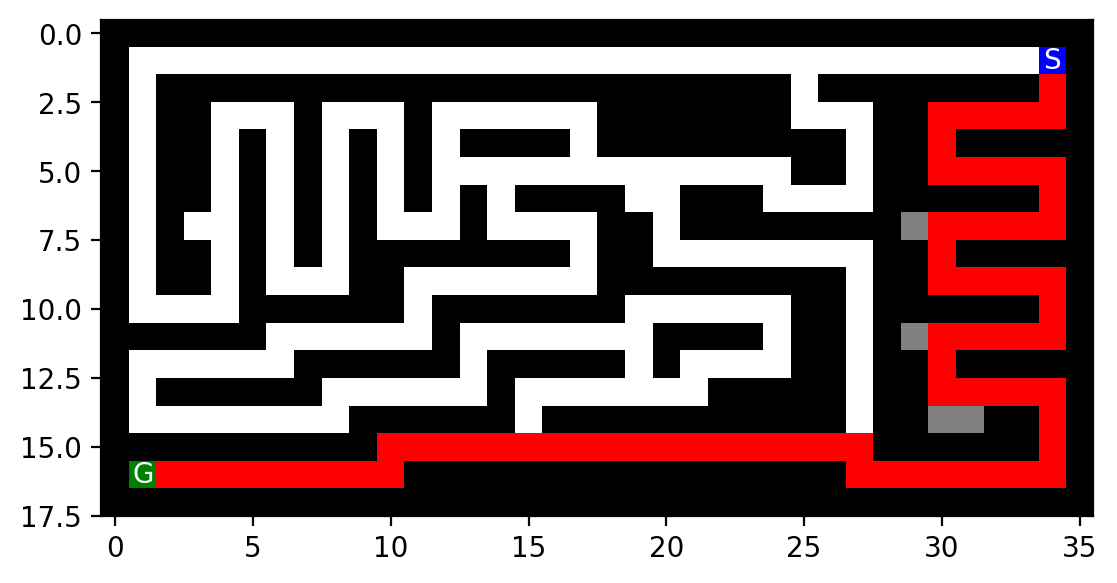


[medium_maze.txt] A* — Detailed Steps
  Start at (np.int64(1), np.int64(34))
  Step 1:     W -> (np.int64(1), np.int64(33))
  Step 2:     W -> (np.int64(1), np.int64(32))
  Step 3:     W -> (np.int64(1), np.int64(31))
  Step 4:     W -> (np.int64(1), np.int64(30))
  Step 5:     W -> (np.int64(1), np.int64(29))
  Step 6:     W -> (np.int64(1), np.int64(28))
  Step 7:     W -> (np.int64(1), np.int64(27))
  Step 8:     W -> (np.int64(1), np.int64(26))
  Step 9:     W -> (np.int64(1), np.int64(25))
  Step 10:     S -> (np.int64(2), np.int64(25))
  Step 11:     S -> (np.int64(3), np.int64(25))
  Step 12:     E -> (np.int64(3), np.int64(26))
  Step 13:     E -> (np.int64(3), np.int64(27))
  Step 14:     S -> (np.int64(4), np.int64(27))
  Step 15:     S -> (np.int64(5), np.int64(27))
  Step 16:     S -> (np.int64(6), np.int64(27))
  Step 17:     W -> (np.int64(6), np.int64(26))
  Step 18:     W -> (np.int64(6), np.int64(25))
  Step 19:     W -> (np.int64(6), np.int64(24))
  Step 20:     N ->

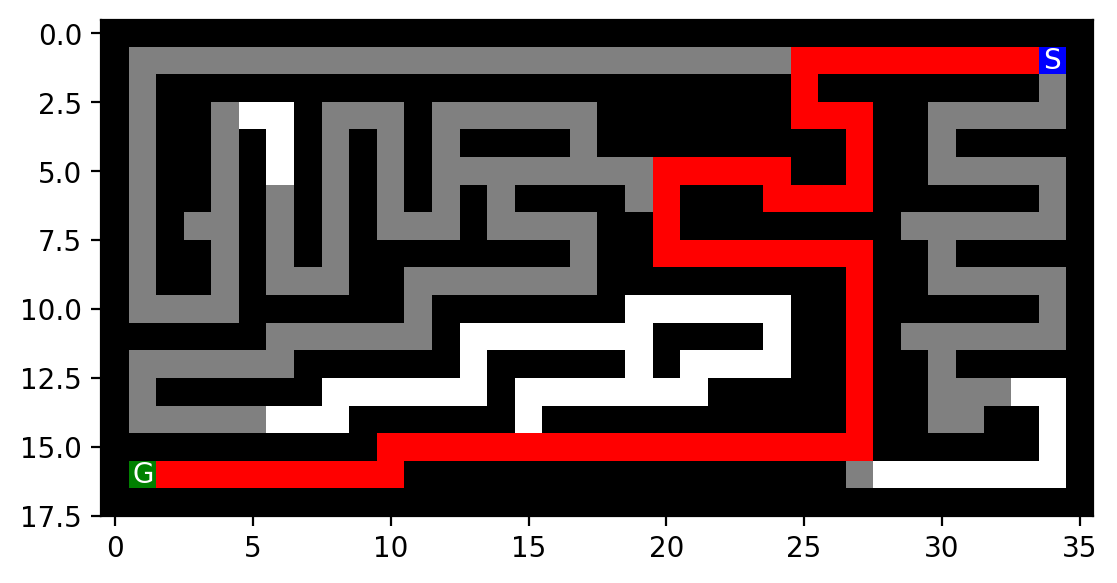


[large_maze.txt] GBFS — Detailed Steps
  Start at (np.int64(35), np.int64(35))
  Step 1:     N -> (np.int64(34), np.int64(35))
  Step 2:     N -> (np.int64(33), np.int64(35))
  Step 3:     W -> (np.int64(33), np.int64(34))
  Step 4:     W -> (np.int64(33), np.int64(33))
  Step 5:     W -> (np.int64(33), np.int64(32))
  Step 6:     W -> (np.int64(33), np.int64(31))
  Step 7:     N -> (np.int64(32), np.int64(31))
  Step 8:     N -> (np.int64(31), np.int64(31))
  Step 9:     W -> (np.int64(31), np.int64(30))
  Step 10:     W -> (np.int64(31), np.int64(29))
  Step 11:     S -> (np.int64(32), np.int64(29))
  Step 12:     S -> (np.int64(33), np.int64(29))
  Step 13:     W -> (np.int64(33), np.int64(28))
  Step 14:     W -> (np.int64(33), np.int64(27))
  Step 15:     W -> (np.int64(33), np.int64(26))
  Step 16:     W -> (np.int64(33), np.int64(25))
  Step 17:     W -> (np.int64(33), np.int64(24))
  Step 18:     W -> (np.int64(33), np.int64(23))
  Step 19:     W -> (np.int64(33), np.int64(22)

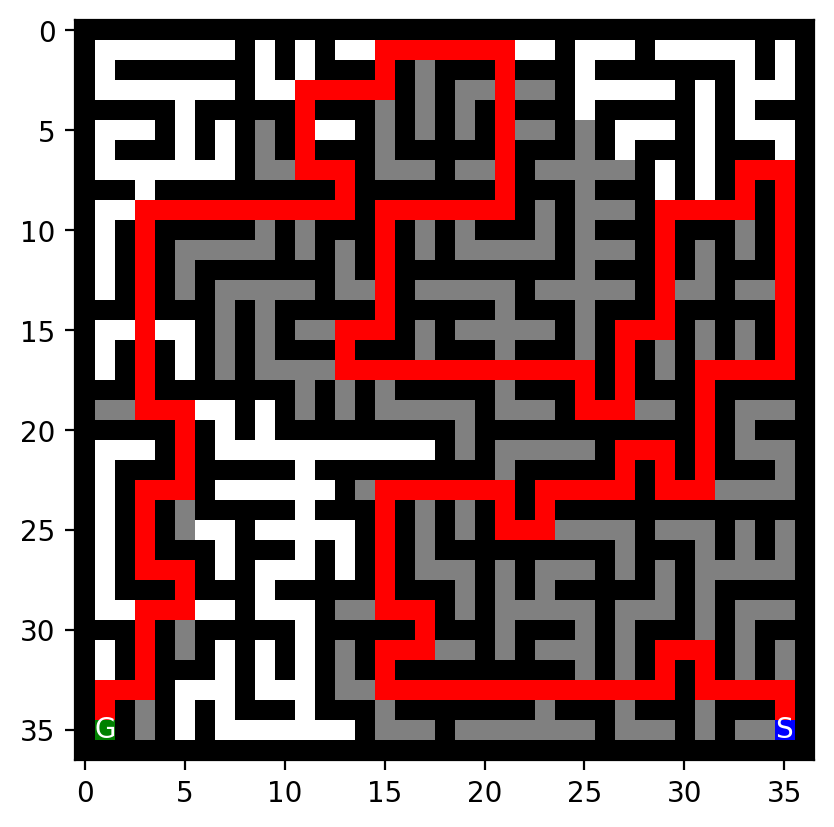


[large_maze.txt] A* — Detailed Steps
  Start at (np.int64(35), np.int64(35))
  Step 1:     N -> (np.int64(34), np.int64(35))
  Step 2:     N -> (np.int64(33), np.int64(35))
  Step 3:     W -> (np.int64(33), np.int64(34))
  Step 4:     W -> (np.int64(33), np.int64(33))
  Step 5:     W -> (np.int64(33), np.int64(32))
  Step 6:     W -> (np.int64(33), np.int64(31))
  Step 7:     N -> (np.int64(32), np.int64(31))
  Step 8:     N -> (np.int64(31), np.int64(31))
  Step 9:     W -> (np.int64(31), np.int64(30))
  Step 10:     W -> (np.int64(31), np.int64(29))
  Step 11:     S -> (np.int64(32), np.int64(29))
  Step 12:     S -> (np.int64(33), np.int64(29))
  Step 13:     W -> (np.int64(33), np.int64(28))
  Step 14:     W -> (np.int64(33), np.int64(27))
  Step 15:     W -> (np.int64(33), np.int64(26))
  Step 16:     W -> (np.int64(33), np.int64(25))
  Step 17:     W -> (np.int64(33), np.int64(24))
  Step 18:     W -> (np.int64(33), np.int64(23))
  Step 19:     W -> (np.int64(33), np.int64(22))


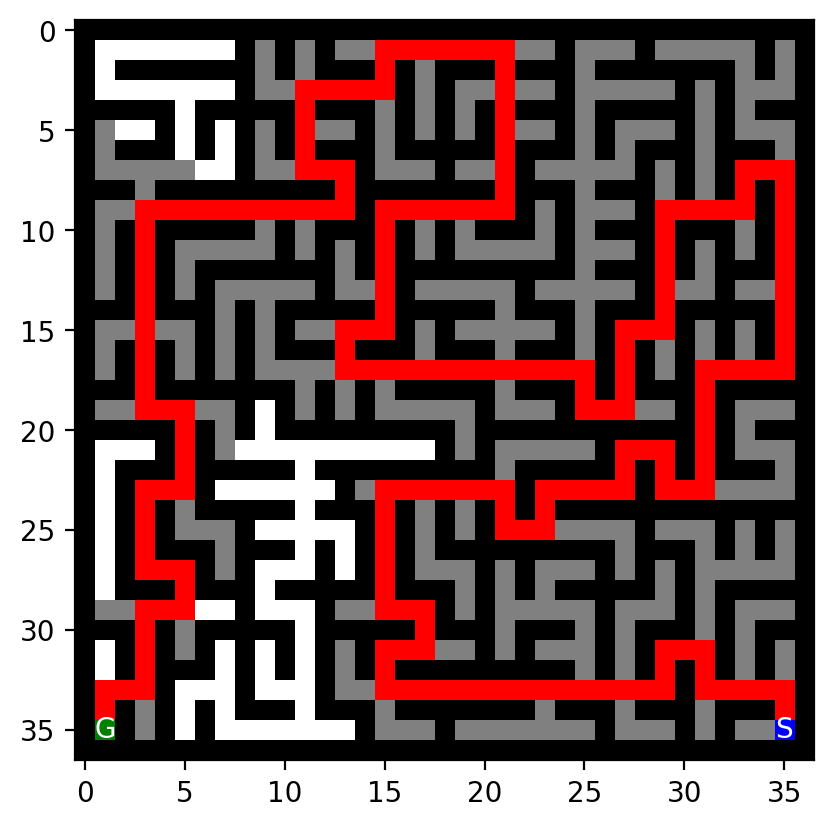


[open_maze.txt] GBFS — Detailed Steps
  Start at (np.int64(1), np.int64(35))
  Step 1:     S -> (np.int64(2), np.int64(35))
  Step 2:     S -> (np.int64(3), np.int64(35))
  Step 3:     S -> (np.int64(4), np.int64(35))
  Step 4:     S -> (np.int64(5), np.int64(35))
  Step 5:     S -> (np.int64(6), np.int64(35))
  Step 6:     S -> (np.int64(7), np.int64(35))
  Step 7:     S -> (np.int64(8), np.int64(35))
  Step 8:     S -> (np.int64(9), np.int64(35))
  Step 9:     S -> (np.int64(10), np.int64(35))
  Step 10:     S -> (np.int64(11), np.int64(35))
  Step 11:     S -> (np.int64(12), np.int64(35))
  Step 12:     S -> (np.int64(13), np.int64(35))
  Step 13:     W -> (np.int64(13), np.int64(34))
  Step 14:     W -> (np.int64(13), np.int64(33))
  Step 15:     W -> (np.int64(13), np.int64(32))
  Step 16:     W -> (np.int64(13), np.int64(31))
  Step 17:     W -> (np.int64(13), np.int64(30))
  Step 18:     W -> (np.int64(13), np.int64(29))
  Step 19:     W -> (np.int64(13), np.int64(28))
  Step 2

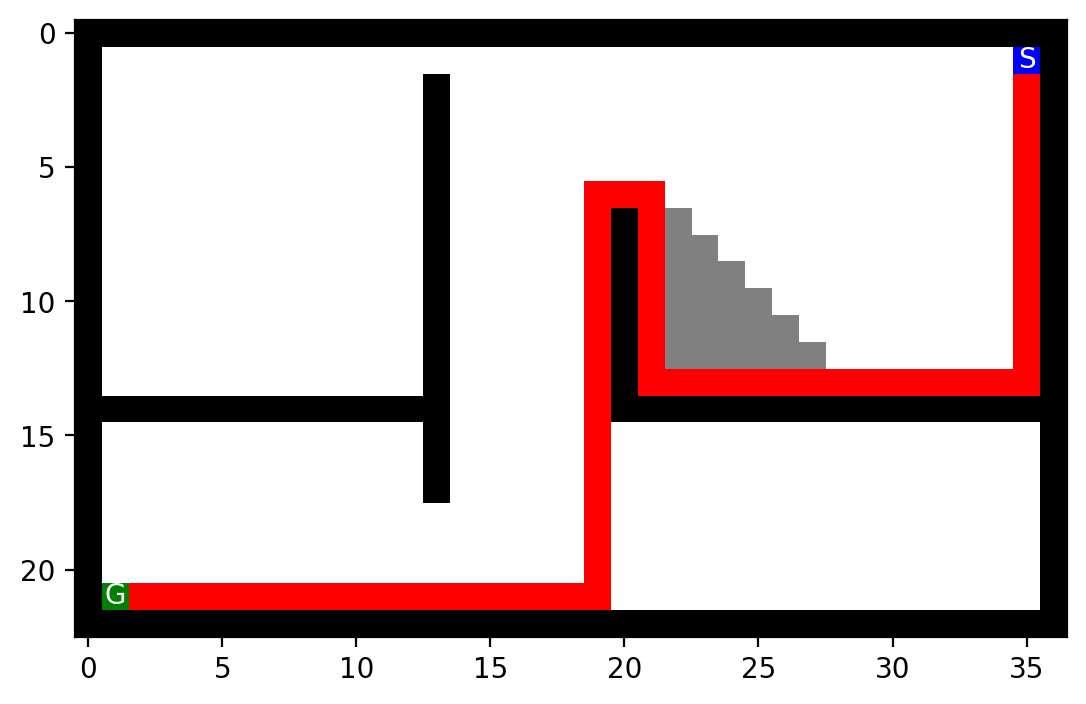


[open_maze.txt] A* — Detailed Steps
  Start at (np.int64(1), np.int64(35))
  Step 1:     S -> (np.int64(2), np.int64(35))
  Step 2:     S -> (np.int64(3), np.int64(35))
  Step 3:     S -> (np.int64(4), np.int64(35))
  Step 4:     S -> (np.int64(5), np.int64(35))
  Step 5:     S -> (np.int64(6), np.int64(35))
  Step 6:     W -> (np.int64(6), np.int64(34))
  Step 7:     W -> (np.int64(6), np.int64(33))
  Step 8:     W -> (np.int64(6), np.int64(32))
  Step 9:     W -> (np.int64(6), np.int64(31))
  Step 10:     W -> (np.int64(6), np.int64(30))
  Step 11:     W -> (np.int64(6), np.int64(29))
  Step 12:     W -> (np.int64(6), np.int64(28))
  Step 13:     W -> (np.int64(6), np.int64(27))
  Step 14:     W -> (np.int64(6), np.int64(26))
  Step 15:     W -> (np.int64(6), np.int64(25))
  Step 16:     W -> (np.int64(6), np.int64(24))
  Step 17:     W -> (np.int64(6), np.int64(23))
  Step 18:     W -> (np.int64(6), np.int64(22))
  Step 19:     W -> (np.int64(6), np.int64(21))
  Step 20:     W -> (

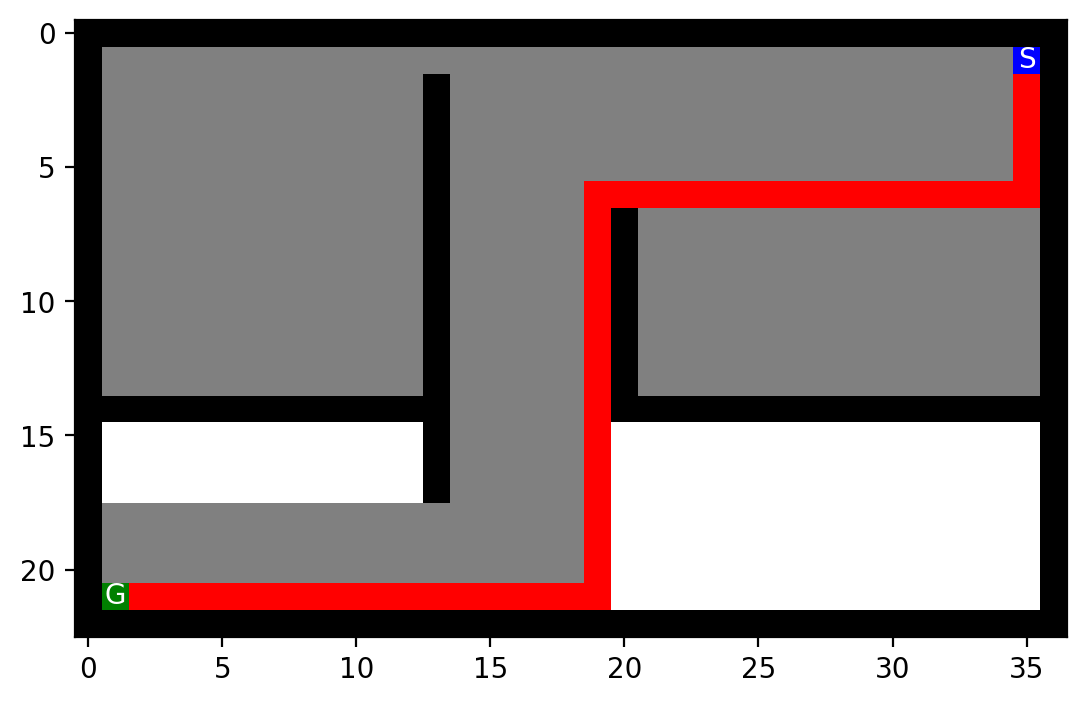


[L_maze.txt] GBFS — Detailed Steps
  Start at (np.int64(9), np.int64(5))
  Step 1:     E -> (np.int64(9), np.int64(6))
  Step 2:     E -> (np.int64(9), np.int64(7))
  Step 3:     E -> (np.int64(9), np.int64(8))
  Step 4:     E -> (np.int64(9), np.int64(9))
  Step 5:     S -> (np.int64(10), np.int64(9))
  Step 6:     E -> (np.int64(10), np.int64(10))
  Step 7:     E -> (np.int64(10), np.int64(11))
  Step 8:     E -> (np.int64(10), np.int64(12))
  Step 9:     N -> (np.int64(9), np.int64(12))
  Step 10:     N -> (np.int64(8), np.int64(12))
  Step 11:     N -> (np.int64(7), np.int64(12))
  Step 12:     N -> (np.int64(6), np.int64(12))
  Step 13:     N -> (np.int64(5), np.int64(12))
  Step 14:     N -> (np.int64(4), np.int64(12))
  Step 15:     N -> (np.int64(3), np.int64(12))
  Step 16:     N -> (np.int64(2), np.int64(12))
  Goal at (np.int64(2), np.int64(12))
  Total path cost: 16



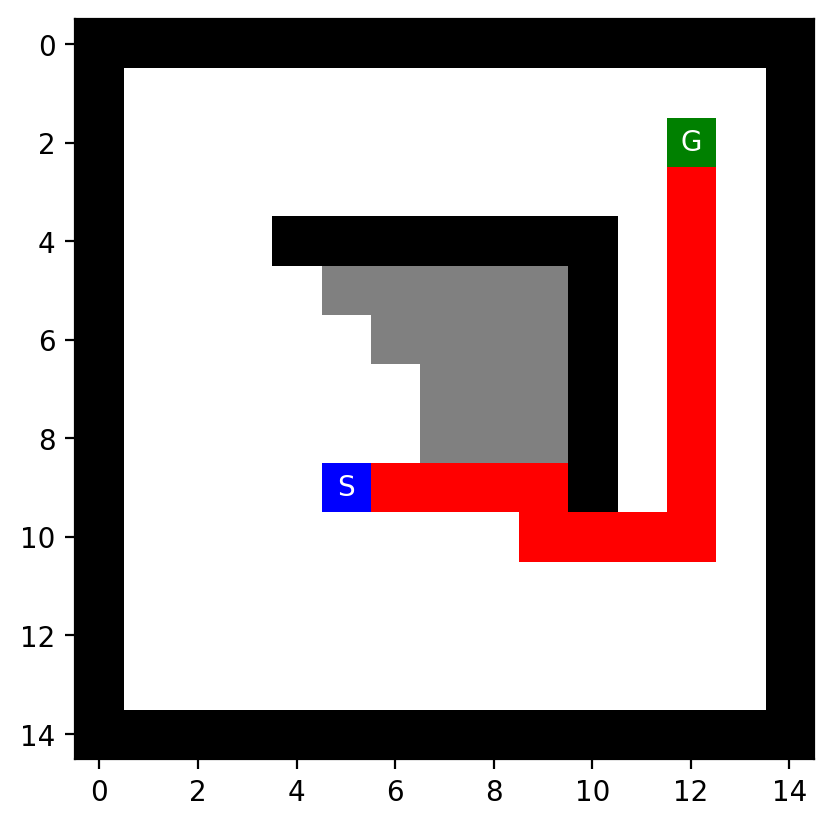


[L_maze.txt] A* — Detailed Steps
  Start at (np.int64(9), np.int64(5))
  Step 1:     E -> (np.int64(9), np.int64(6))
  Step 2:     E -> (np.int64(9), np.int64(7))
  Step 3:     E -> (np.int64(9), np.int64(8))
  Step 4:     E -> (np.int64(9), np.int64(9))
  Step 5:     S -> (np.int64(10), np.int64(9))
  Step 6:     E -> (np.int64(10), np.int64(10))
  Step 7:     E -> (np.int64(10), np.int64(11))
  Step 8:     E -> (np.int64(10), np.int64(12))
  Step 9:     N -> (np.int64(9), np.int64(12))
  Step 10:     N -> (np.int64(8), np.int64(12))
  Step 11:     N -> (np.int64(7), np.int64(12))
  Step 12:     N -> (np.int64(6), np.int64(12))
  Step 13:     N -> (np.int64(5), np.int64(12))
  Step 14:     N -> (np.int64(4), np.int64(12))
  Step 15:     N -> (np.int64(3), np.int64(12))
  Step 16:     N -> (np.int64(2), np.int64(12))
  Goal at (np.int64(2), np.int64(12))
  Total path cost: 16



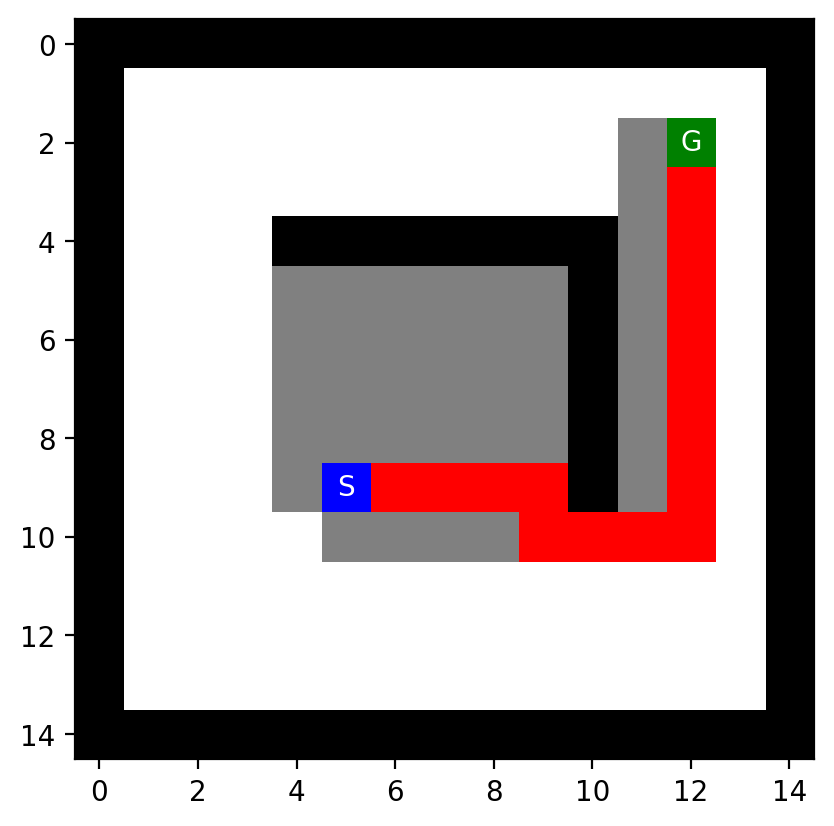


[loops_maze.txt] GBFS — Detailed Steps
  Start at (np.int64(10), np.int64(1))
  Step 1:     E -> (np.int64(10), np.int64(2))
  Step 2:     E -> (np.int64(10), np.int64(3))
  Step 3:     E -> (np.int64(10), np.int64(4))
  Step 4:     E -> (np.int64(10), np.int64(5))
  Step 5:     E -> (np.int64(10), np.int64(6))
  Step 6:     E -> (np.int64(10), np.int64(7))
  Step 7:     E -> (np.int64(10), np.int64(8))
  Step 8:     N -> (np.int64(9), np.int64(8))
  Step 9:     N -> (np.int64(8), np.int64(8))
  Step 10:     N -> (np.int64(7), np.int64(8))
  Step 11:     N -> (np.int64(6), np.int64(8))
  Step 12:     N -> (np.int64(5), np.int64(8))
  Step 13:     N -> (np.int64(4), np.int64(8))
  Step 14:     N -> (np.int64(3), np.int64(8))
  Step 15:     N -> (np.int64(2), np.int64(8))
  Step 16:     W -> (np.int64(2), np.int64(7))
  Step 17:     W -> (np.int64(2), np.int64(6))
  Step 18:     W -> (np.int64(2), np.int64(5))
  Step 19:     W -> (np.int64(2), np.int64(4))
  Step 20:     W -> (np.int64(

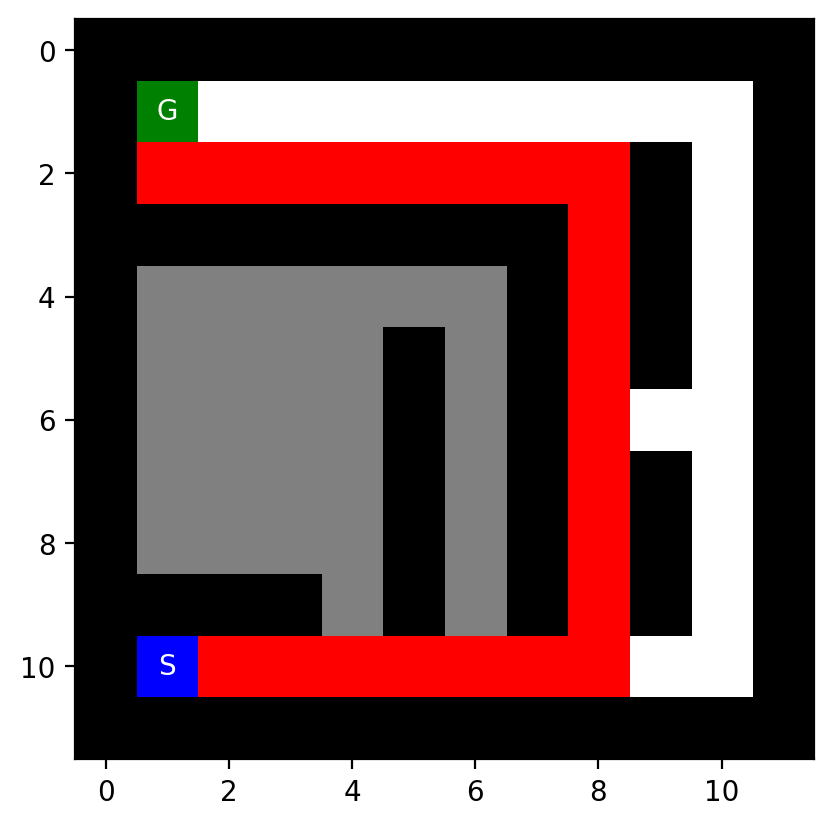


[loops_maze.txt] A* — Detailed Steps
  Start at (np.int64(10), np.int64(1))
  Step 1:     E -> (np.int64(10), np.int64(2))
  Step 2:     E -> (np.int64(10), np.int64(3))
  Step 3:     E -> (np.int64(10), np.int64(4))
  Step 4:     E -> (np.int64(10), np.int64(5))
  Step 5:     E -> (np.int64(10), np.int64(6))
  Step 6:     E -> (np.int64(10), np.int64(7))
  Step 7:     E -> (np.int64(10), np.int64(8))
  Step 8:     N -> (np.int64(9), np.int64(8))
  Step 9:     N -> (np.int64(8), np.int64(8))
  Step 10:     N -> (np.int64(7), np.int64(8))
  Step 11:     N -> (np.int64(6), np.int64(8))
  Step 12:     N -> (np.int64(5), np.int64(8))
  Step 13:     N -> (np.int64(4), np.int64(8))
  Step 14:     N -> (np.int64(3), np.int64(8))
  Step 15:     N -> (np.int64(2), np.int64(8))
  Step 16:     W -> (np.int64(2), np.int64(7))
  Step 17:     W -> (np.int64(2), np.int64(6))
  Step 18:     W -> (np.int64(2), np.int64(5))
  Step 19:     W -> (np.int64(2), np.int64(4))
  Step 20:     W -> (np.int64(2)

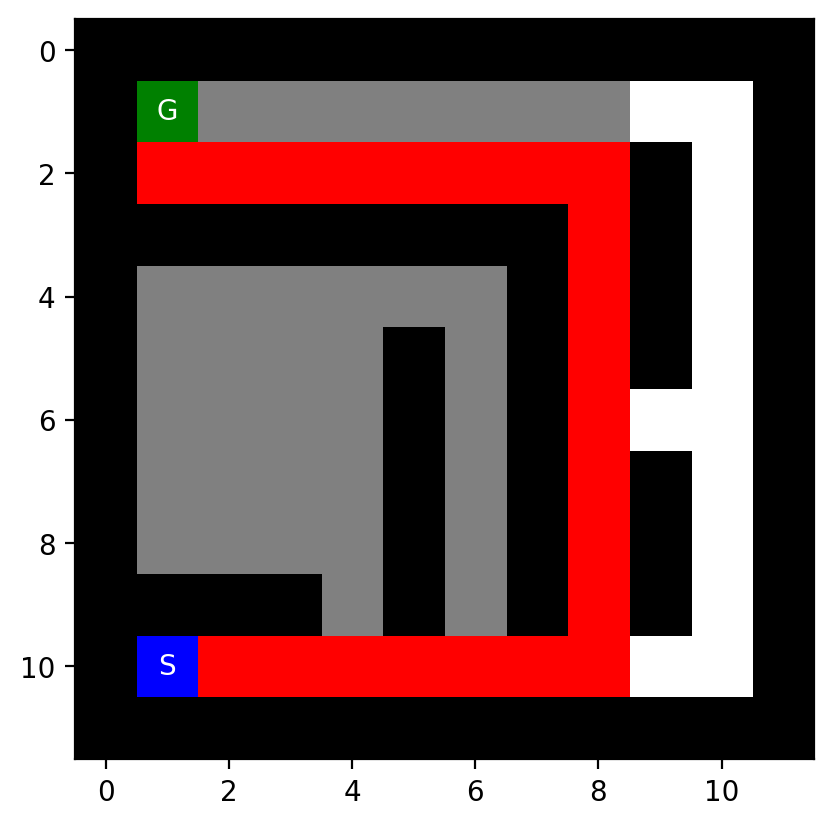


[empty_maze.txt] GBFS — Detailed Steps
  Start at (np.int64(9), np.int64(2))
  Step 1:     E -> (np.int64(9), np.int64(3))
  Step 2:     E -> (np.int64(9), np.int64(4))
  Step 3:     E -> (np.int64(9), np.int64(5))
  Step 4:     E -> (np.int64(9), np.int64(6))
  Step 5:     E -> (np.int64(9), np.int64(7))
  Step 6:     E -> (np.int64(9), np.int64(8))
  Step 7:     E -> (np.int64(9), np.int64(9))
  Step 8:     N -> (np.int64(8), np.int64(9))
  Step 9:     N -> (np.int64(7), np.int64(9))
  Step 10:     N -> (np.int64(6), np.int64(9))
  Step 11:     N -> (np.int64(5), np.int64(9))
  Step 12:     N -> (np.int64(4), np.int64(9))
  Step 13:     N -> (np.int64(3), np.int64(9))
  Step 14:     N -> (np.int64(2), np.int64(9))
  Goal at (np.int64(2), np.int64(9))
  Total path cost: 14



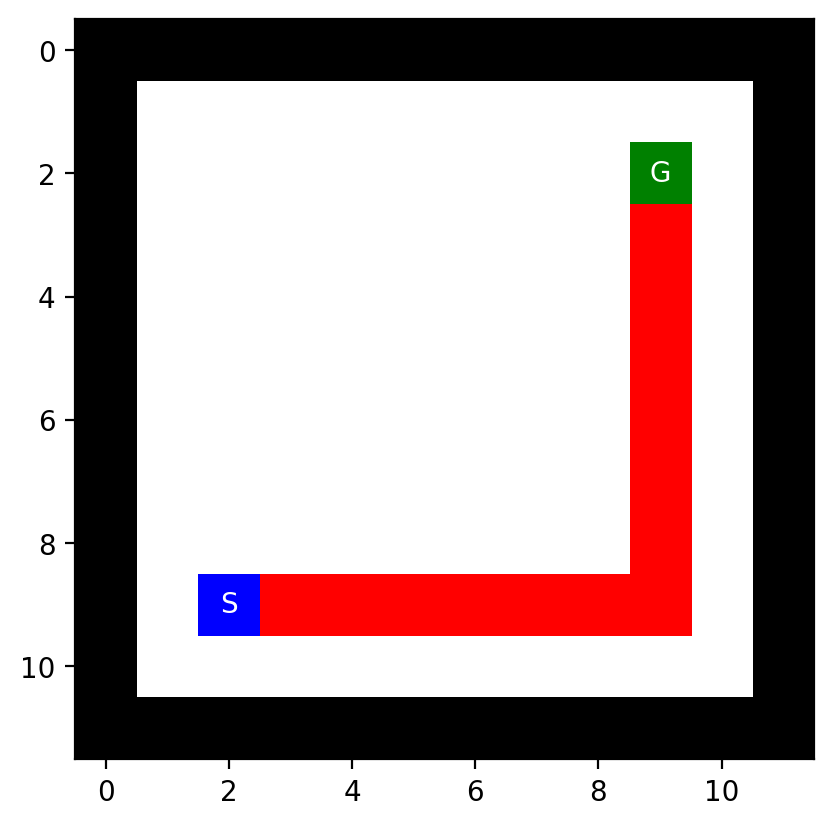


[empty_maze.txt] A* — Detailed Steps
  Start at (np.int64(9), np.int64(2))
  Step 1:     E -> (np.int64(9), np.int64(3))
  Step 2:     E -> (np.int64(9), np.int64(4))
  Step 3:     E -> (np.int64(9), np.int64(5))
  Step 4:     E -> (np.int64(9), np.int64(6))
  Step 5:     E -> (np.int64(9), np.int64(7))
  Step 6:     E -> (np.int64(9), np.int64(8))
  Step 7:     E -> (np.int64(9), np.int64(9))
  Step 8:     N -> (np.int64(8), np.int64(9))
  Step 9:     N -> (np.int64(7), np.int64(9))
  Step 10:     N -> (np.int64(6), np.int64(9))
  Step 11:     N -> (np.int64(5), np.int64(9))
  Step 12:     N -> (np.int64(4), np.int64(9))
  Step 13:     N -> (np.int64(3), np.int64(9))
  Step 14:     N -> (np.int64(2), np.int64(9))
  Goal at (np.int64(2), np.int64(9))
  Total path cost: 14



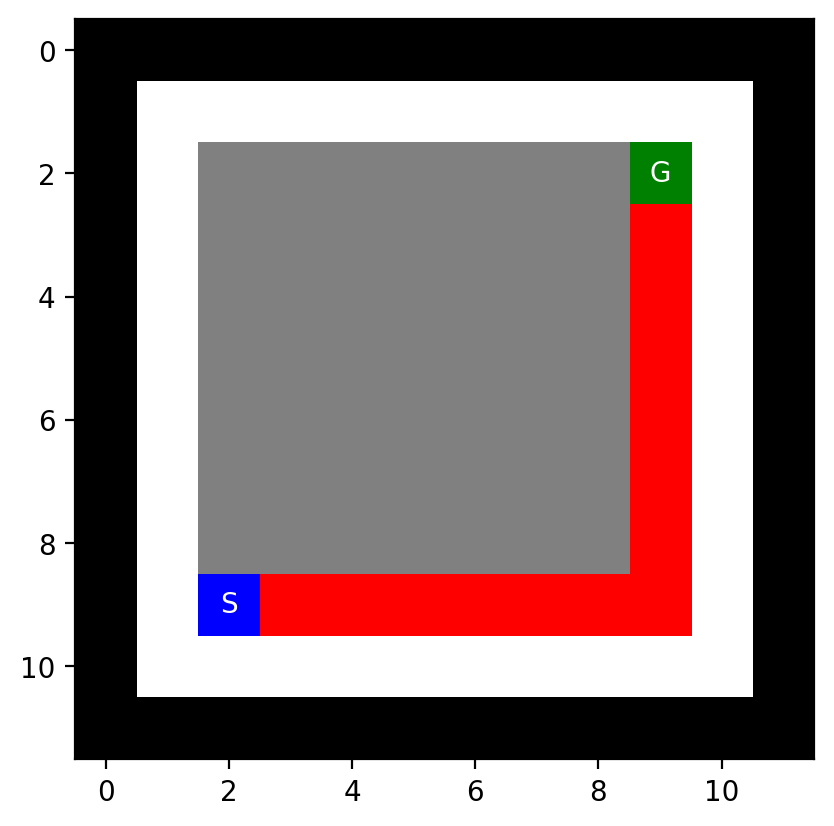


[empty_maze_2.txt] GBFS — Detailed Steps
  Start at (np.int64(2), np.int64(9))
  Step 1:     S -> (np.int64(3), np.int64(9))
  Step 2:     S -> (np.int64(4), np.int64(9))
  Step 3:     S -> (np.int64(5), np.int64(9))
  Step 4:     S -> (np.int64(6), np.int64(9))
  Step 5:     S -> (np.int64(7), np.int64(9))
  Step 6:     S -> (np.int64(8), np.int64(9))
  Step 7:     S -> (np.int64(9), np.int64(9))
  Step 8:     W -> (np.int64(9), np.int64(8))
  Step 9:     W -> (np.int64(9), np.int64(7))
  Step 10:     W -> (np.int64(9), np.int64(6))
  Step 11:     W -> (np.int64(9), np.int64(5))
  Step 12:     W -> (np.int64(9), np.int64(4))
  Step 13:     W -> (np.int64(9), np.int64(3))
  Step 14:     W -> (np.int64(9), np.int64(2))
  Goal at (np.int64(9), np.int64(2))
  Total path cost: 14



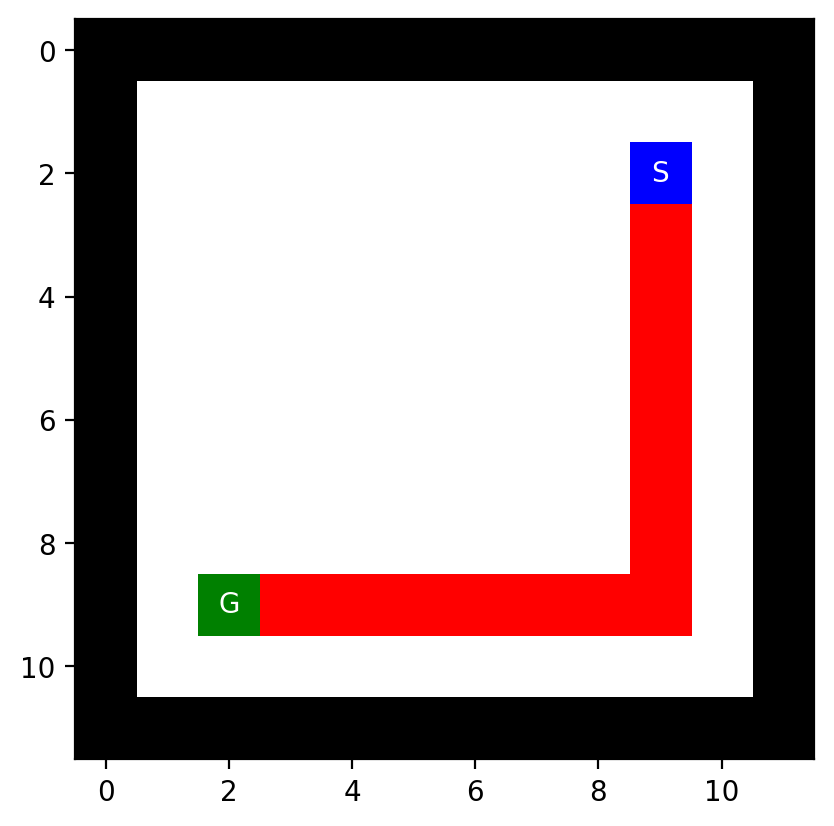


[empty_maze_2.txt] A* — Detailed Steps
  Start at (np.int64(2), np.int64(9))
  Step 1:     S -> (np.int64(3), np.int64(9))
  Step 2:     S -> (np.int64(4), np.int64(9))
  Step 3:     S -> (np.int64(5), np.int64(9))
  Step 4:     S -> (np.int64(6), np.int64(9))
  Step 5:     S -> (np.int64(7), np.int64(9))
  Step 6:     S -> (np.int64(8), np.int64(9))
  Step 7:     S -> (np.int64(9), np.int64(9))
  Step 8:     W -> (np.int64(9), np.int64(8))
  Step 9:     W -> (np.int64(9), np.int64(7))
  Step 10:     W -> (np.int64(9), np.int64(6))
  Step 11:     W -> (np.int64(9), np.int64(5))
  Step 12:     W -> (np.int64(9), np.int64(4))
  Step 13:     W -> (np.int64(9), np.int64(3))
  Step 14:     W -> (np.int64(9), np.int64(2))
  Goal at (np.int64(9), np.int64(2))
  Total path cost: 14



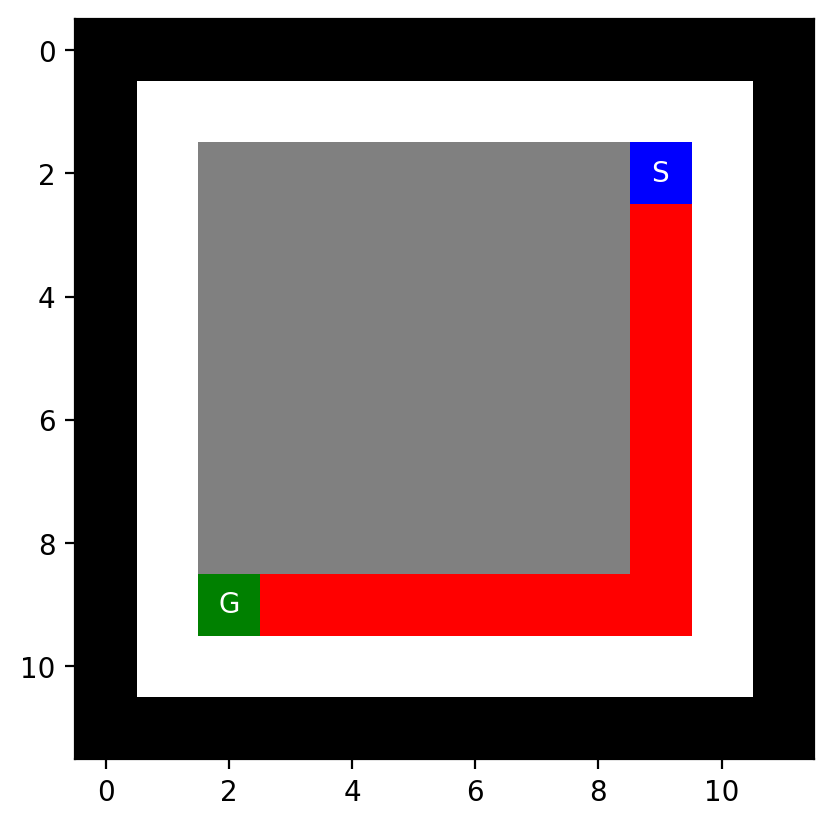


=== Search Results ===
            Maze Algorithm  Path Cost  Nodes Expanded  Max Frontier Size  Max Depth Reached
  small_maze.txt      GBFS         29              40                  5                 29
  small_maze.txt        A*         19              54                  8                 19
 medium_maze.txt      GBFS         74              79                  4                 74
 medium_maze.txt        A*         68             222                  8                 68
  large_maze.txt      GBFS        210             468                 20                210
  large_maze.txt        A*        210             550                 12                210
   open_maze.txt      GBFS         68              90                 66                 68
   open_maze.txt        A*         54             536                 25                 54
      L_maze.txt      GBFS         16              32                 30                 16
      L_maze.txt        A*         16              54   

In [16]:
# Your code goes here

import heapq
import numpy as np
import pandas as pd
import maze_helper as mh

# Same direction order as your Task 2 runner (keep consistent across algs)
DIRS = [("E", (0, 1)), ("S", (1, 0)), ("W", (0, -1)), ("N", (-1, 0))]

def in_bounds(maze, p):
    r, c = p
    return 0 <= r < maze.shape[0] and 0 <= c < maze.shape[1]

def open_cell(maze, p):
    return mh.look(maze, p) != "X"

def succ(maze, p):
    r, c = p
    for a, (dr, dc) in DIRS:
        q = (r + dr, c + dc)
        if in_bounds(maze, q) and open_cell(maze, q):
            yield a, q

def manhattan(p, g):
    return abs(p[0] - g[0]) + abs(p[1] - g[1])

class Node:
    __slots__ = ("pos", "parent", "action", "depth")
    def __init__(self, pos, parent=None, action=None, depth=0):
        self.pos = tuple(pos)
        self.parent = parent
        self.action = action
        self.depth = depth

def path_positions(goal_node):
    out = []
    cur = goal_node
    while cur is not None:
        out.append(cur.pos)
        cur = cur.parent
    out.reverse()
    return out

def path_actions(goal_node):
    out = []
    cur = goal_node
    while cur is not None and cur.parent is not None:
        out.append(cur.action)
        cur = cur.parent
    out.reverse()
    return out

def print_steps(maze_name, alg_name, start, goal, actions, positions):
    print(f"\n[{maze_name}] {alg_name} — Detailed Steps")
    if actions is None:
        print("  Goal not found.")
        return
    print(f"  Start at {start}")
    for i, (a, p) in enumerate(zip(actions, positions[1:]), start=1):
        print(f"  Step {i}: {a.upper():>5} -> {p}")
    print(f"  Goal at {goal}")
    print(f"  Total path cost: {len(actions)}\n")

def draw_solution(maze, expanded, goal_node):
    M = np.copy(maze)
    s = mh.find_pos(M, what="S")
    g = mh.find_pos(M, what="G")

    for p in expanded:
        if p != s and p != g and M[p] == " ":
            M[p] = "."

    if goal_node is not None:
        for p in path_positions(goal_node):
            if p != s and p != g and M[p] in [" ", "."]:
                M[p] = "P"

    M[s] = "S"
    M[g] = "G"
    mh.show_maze(M)

def gbfs(maze, start, goal):
    """
    Greedy Best-First Search: priority = h(n)
    """
    root = Node(start)
    frontier = []
    tie = 0
    heapq.heappush(frontier, (manhattan(root.pos, goal), tie, root))

    reached = {root.pos}
    expanded = set()

    nodes_expanded = 0
    max_depth = 0
    max_frontier = 1

    while frontier:
        max_frontier = max(max_frontier, len(frontier))
        _, _, node = heapq.heappop(frontier)

        nodes_expanded += 1
        expanded.add(node.pos)
        max_depth = max(max_depth, node.depth)

        if node.pos == goal:
            return node, expanded, nodes_expanded, max_depth, max_frontier

        for a, q in succ(maze, node.pos):
            if q not in reached:
                reached.add(q)
                child = Node(q, node, a, node.depth + 1)
                tie += 1
                heapq.heappush(frontier, (manhattan(q, goal), tie, child))

    return None, expanded, nodes_expanded, max_depth, max_frontier

def astar(maze, start, goal):
    """
    A* Search: priority = f(n) = g(n) + h(n)
    Correctly tracks best known g for each state.
    """
    root = Node(start)
    frontier = []
    tie = 0

    best_g = {root.pos: 0}
    heapq.heappush(frontier, (0 + manhattan(root.pos, goal), tie, root))

    expanded = set()
    nodes_expanded = 0
    max_depth = 0
    max_frontier = 1

    while frontier:
        max_frontier = max(max_frontier, len(frontier))
        _, _, node = heapq.heappop(frontier)

        # skip stale entries
        if node.depth != best_g.get(node.pos, None):
            continue

        nodes_expanded += 1
        expanded.add(node.pos)
        max_depth = max(max_depth, node.depth)

        if node.pos == goal:
            return node, expanded, nodes_expanded, max_depth, max_frontier

        for a, q in succ(maze, node.pos):
            g2 = node.depth + 1
            if (q not in best_g) or (g2 < best_g[q]):
                best_g[q] = g2
                child = Node(q, node, a, g2)
                tie += 1
                f2 = g2 + manhattan(q, goal)
                heapq.heappush(frontier, (f2, tie, child))

    return None, expanded, nodes_expanded, max_depth, max_frontier

def run_task3_all():
    maze_files = [
        "small_maze.txt","medium_maze.txt","large_maze.txt","open_maze.txt",
        "L_maze.txt","loops_maze.txt","empty_maze.txt","empty_maze_2.txt"
    ]

    rows = []

    for mf in maze_files:
        with open(mf, "r") as f:
            txt = f.read()

        maze = mh.parse_maze(txt)
        start = mh.find_pos(maze, what="S")
        goal = mh.find_pos(maze, what="G")

        for name, fn in [("GBFS", gbfs), ("A*", astar)]:
            goal_node, expanded, n_exp, m_depth, m_front = fn(maze, start, goal)

            actions = path_actions(goal_node) if goal_node else None
            positions = path_positions(goal_node) if goal_node else None

            print_steps(mf, name, start, goal, actions, positions)
            draw_solution(maze, expanded, goal_node)

            rows.append({
                "Maze": mf,
                "Algorithm": name,
                "Path Cost": (len(actions) if actions else None),
                "Nodes Expanded": n_exp,
                "Max Frontier Size": m_front,
                "Max Depth Reached": m_depth
            })

    df = pd.DataFrame(rows, columns=[
        "Maze","Algorithm","Path Cost","Nodes Expanded","Max Frontier Size","Max Depth Reached"
    ])
    print("\n=== Search Results ===")
    print(df.to_string(index=False))
    return df

df_task3 = run_task3_all()

Are your implementations complete and optimal? What is the time and space complexity?

* **GBFS:** It is not optimal because it only follows the heuristic and can take a longer route if the heuristic points into a dead-end-ish area. With a reached set in a finite maze, it is effectively complete (it will eventually stop and either find the goal or exhaust states), but it can still do a lot of unnecessary work if the heuristic misleads it. Time/space can still blow up in worst cases (exponential-style in terms of branching and depth), since it may explore a large portion of the maze.

* A* : With Manhattan distance on a 4-neighbor grid, the heuristic does not overestimate the true remaining distance, so A* is optimal (returns a shortest path) as long as we keep the best known g-cost per state (which this implementation does). A* is also complete in a finite maze with positive step costs. Worst-case time is still exponential in theory, but in practice A* usually expands much fewer nodes than BFS when the heuristic is informative. The tradeoff is memory: A* can use a lot of space because it stores a priority frontier and best-cost records.

In [ ]:
# Discussion

## Task 4: Comparison and discussion [20 Points]

Run experiments to compare the implemented algorithms.

How to deal with issues:

* Your implementation returns unexpected results: Try to debug and fix the code. Visualizing the maze, the current path and the frontier after every step is very helpful. If the code still does not work, then mark the result with an asterisk (*) and describe the issue below the table.

* Your implementation cannot consistently solve a specific maze and ends up in an infinite loop:
    Debug (likely your frontier and cycle checking for DFS are the issue). If it is a shortcoming of the algorithm/implementation, then put "N/A*" in the results table and describe why this is happening.

In [20]:
# Add code
import numpy as np
import pandas as pd
import heapq
import matplotlib.pyplot as plt
import maze_helper as mh
from collections import deque

# --------------------------
# Maze list (assignment)
# --------------------------
MAZE_FILES = [
    "small_maze.txt",
    "medium_maze.txt",
    "large_maze.txt",
    "open_maze.txt",
    "L_maze.txt",
    "loops_maze.txt",
    "empty_maze.txt",
    "empty_maze_2.txt",
]

# Use the same direction order across all algorithms for fair comparison
DIRS = [("E", (0, 1)), ("S", (1, 0)), ("W", (0, -1)), ("N", (-1, 0))]

def in_bounds(maze, p):
    r, c = p
    return 0 <= r < maze.shape[0] and 0 <= c < maze.shape[1]

def passable(maze, p):
    return mh.look(maze, p) != "X"

def succ(maze, p):
    r, c = p
    for a, (dr, dc) in DIRS:
        q = (r + dr, c + dc)
        if in_bounds(maze, q) and passable(maze, q):
            yield a, q

def manhattan(p, g):
    return abs(p[0] - g[0]) + abs(p[1] - g[1])

class Node:
    __slots__ = ("pos", "parent", "action", "depth", "_expanded", "_next_i")
    def __init__(self, pos, parent=None, action=None, depth=0):
        self.pos = tuple(pos)
        self.parent = parent
        self.action = action
        self.depth = depth
        # DFS bookkeeping:
        self._expanded = False
        self._next_i = 0

def path_actions(goal_node):
    if goal_node is None:
        return None
    out = []
    cur = goal_node
    while cur.parent is not None:
        out.append(cur.action)
        cur = cur.parent
    out.reverse()
    return out

# --------------------------
# Instrumented BFS (graph search with reached)
# --------------------------
def bfs_metrics(maze, start, goal):
    root = Node(start)
    frontier = deque([root])
    reached = {root.pos}

    nodes_expanded = 0
    max_depth = 0
    max_frontier = len(frontier)
    max_reached = len(reached)

    while frontier:
        max_frontier = max(max_frontier, len(frontier))
        max_reached = max(max_reached, len(reached))

        node = frontier.popleft()
        nodes_expanded += 1
        max_depth = max(max_depth, node.depth)

        if node.pos == goal:
            plan = path_actions(node)
            # "nodes in memory" = frontier + reached (standard accounting)
            max_memory = max_frontier + max_reached
            return {
                "path_cost": node.depth,
                "nodes_expanded": nodes_expanded,
                "max_tree_depth": max_depth,
                "max_frontier": max_frontier,
                "max_memory": max_memory,
                "plan": plan,
            }

        for a, q in succ(maze, node.pos):
            if q not in reached:
                reached.add(q)
                frontier.append(Node(q, node, a, node.depth + 1))

    return None  # no solution

# --------------------------
# Instrumented DFS (proper: no reached; cycle-checking only; memory released)
# --------------------------
def dfs_metrics(maze, start, goal, step_cap=2_000_000):
    root = Node(start)
    stack = [root]
    on_path = {root.pos}

    nodes_expanded = 0
    max_depth = 0
    max_frontier = len(stack)  # stack size is DFS frontier
    steps = 0

    # For DFS, "memory" is basically current path/stack + on_path bookkeeping
    # (they are same size), so memory ~ stack size.
    max_memory = len(stack)

    while stack:
        steps += 1
        if steps > step_cap:
            return "N/A*", {"note": f"DFS hit step cap ({step_cap}). Likely heavy revisiting in open spaces."}

        max_frontier = max(max_frontier, len(stack))
        max_memory = max(max_memory, len(stack))

        node = stack[-1]

        if node.pos == goal:
            plan = path_actions(node)
            return {
                "path_cost": node.depth,
                "nodes_expanded": nodes_expanded,
                "max_tree_depth": max_depth,
                "max_frontier": max_frontier,
                "max_memory": max_memory,
                "plan": plan,
            }

        if not node._expanded:
            node._expanded = True
            nodes_expanded += 1
            max_depth = max(max_depth, node.depth)

        if node._next_i >= len(DIRS):
            stack.pop()
            on_path.remove(node.pos)
            continue

        a, (dr, dc) = DIRS[node._next_i]
        node._next_i += 1
        q = (node.pos[0] + dr, node.pos[1] + dc)

        if not (in_bounds(maze, q) and passable(maze, q)):
            continue
        if q in on_path:
            continue  # cycle check only

        child = Node(q, node, a, node.depth + 1)
        stack.append(child)
        on_path.add(q)

    return None  # no solution

# --------------------------
# Instrumented GBFS (priority = h)
# --------------------------
def gbfs_metrics(maze, start, goal):
    root = Node(start)
    tie = 0
    frontier = []
    heapq.heappush(frontier, (manhattan(root.pos, goal), tie, root))

    reached = {root.pos}
    nodes_expanded = 0
    max_depth = 0
    max_frontier = len(frontier)
    max_reached = len(reached)

    while frontier:
        max_frontier = max(max_frontier, len(frontier))
        max_reached = max(max_reached, len(reached))

        _, _, node = heapq.heappop(frontier)
        nodes_expanded += 1
        max_depth = max(max_depth, node.depth)

        if node.pos == goal:
            plan = path_actions(node)
            max_memory = max_frontier + max_reached
            return {
                "path_cost": node.depth,
                "nodes_expanded": nodes_expanded,
                "max_tree_depth": max_depth,
                "max_frontier": max_frontier,
                "max_memory": max_memory,
                "plan": plan,
            }

        for a, q in succ(maze, node.pos):
            if q not in reached:
                reached.add(q)
                child = Node(q, node, a, node.depth + 1)
                tie += 1
                heapq.heappush(frontier, (manhattan(q, goal), tie, child))

    return None

# --------------------------
# Instrumented A* (priority = g + h) with best_g
# --------------------------
def astar_metrics(maze, start, goal):
    root = Node(start)
    tie = 0
    frontier = []
    best_g = {root.pos: 0}

    heapq.heappush(frontier, (0 + manhattan(root.pos, goal), tie, root))

    nodes_expanded = 0
    max_depth = 0
    max_frontier = len(frontier)
    max_bestg = len(best_g)

    while frontier:
        max_frontier = max(max_frontier, len(frontier))
        max_bestg = max(max_bestg, len(best_g))

        _, _, node = heapq.heappop(frontier)

        # ignore stale entries
        if node.depth != best_g.get(node.pos, None):
            continue

        nodes_expanded += 1
        max_depth = max(max_depth, node.depth)

        if node.pos == goal:
            plan = path_actions(node)
            max_memory = max_frontier + max_bestg
            return {
                "path_cost": node.depth,
                "nodes_expanded": nodes_expanded,
                "max_tree_depth": max_depth,
                "max_frontier": max_frontier,
                "max_memory": max_memory,
                "plan": plan,
            }

        for a, q in succ(maze, node.pos):
            g2 = node.depth + 1
            if (q not in best_g) or (g2 < best_g[q]):
                best_g[q] = g2
                child = Node(q, node, a, g2)
                tie += 1
                f2 = g2 + manhattan(q, goal)
                heapq.heappush(frontier, (f2, tie, child))

    return None

# --------------------------
# Run experiments + build per-maze table
# --------------------------
ALGORITHMS = [
    ("BFS", bfs_metrics),
    ("DFS", dfs_metrics),
    ("GBS", gbfs_metrics),   # prompt uses "GBS" label
    ("A*",  astar_metrics),
]

results = []
notes = []

for mf in MAZE_FILES:
    with open(mf, "r") as f:
        maze_txt = f.read()
    maze = mh.parse_maze(maze_txt)
    start = mh.find_pos(maze, what="S")
    goal  = mh.find_pos(maze, what="G")

    for alg_name, alg_fn in ALGORITHMS:
        out = alg_fn(maze, start, goal)

        # handle DFS "N/A*" special return
        if isinstance(out, tuple) and out[0] == "N/A*":
            results.append({
                "maze": mf,
                "algorithm": alg_name,
                "path cost": "N/A*",
                "# of nodes expanded": "N/A*",
                "max tree depth": "N/A*",
                "max # of nodes in memory": "N/A*",
                "max frontier size": "N/A*",
            })
            notes.append(f"{mf} / {alg_name}: {out[1]['note']}")
            continue

        if out is None:
            results.append({
                "maze": mf,
                "algorithm": alg_name,
                "path cost": "N/A*",
                "# of nodes expanded": "N/A*",
                "max tree depth": "N/A*",
                "max # of nodes in memory": "N/A*",
                "max frontier size": "N/A*",
            })
            notes.append(f"{mf} / {alg_name}: Goal not found (unexpected) — check successor legality.")
            continue

        results.append({
            "maze": mf,
            "algorithm": alg_name,
            "path cost": out["path_cost"],
            "# of nodes expanded": out["nodes_expanded"],
            "max tree depth": out["max_tree_depth"],
            "max # of nodes in memory": out["max_memory"],
            "max frontier size": out["max_frontier"],
        })

df4 = pd.DataFrame(results, columns=[
    "maze", "algorithm", "path cost", "# of nodes expanded",
    "max tree depth", "max # of nodes in memory", "max frontier size"
])

df4

,maze,algorithm,path cost,# of nodes expanded,max tree depth,max # of nodes in memory,max frontier size
0,small_maze.txt,BFS,19,93,19,103,9
1,small_maze.txt,DFS,37,37,36,38,38
2,small_maze.txt,GBS,29,40,29,49,5
3,small_maze.txt,A*,19,54,19,67,8
4,medium_maze.txt,BFS,68,269,68,280,9
5,medium_maze.txt,DFS,74,74,73,75,75
6,medium_maze.txt,GBS,74,79,74,86,4
7,medium_maze.txt,A*,68,222,68,236,8
8,large_maze.txt,BFS,210,621,210,633,8
9,large_maze.txt,DFS,210,417,222,223,223


Complete the following table for each maze.

__Small maze__

| algorithm | path cost | # of nodes expanded | max tree depth | max # of nodes in memory | max frontier size |
|-----------|-----------|----------------|----------------|---------------|-------------------|
| BFS       |           |                |                |               |                   |
| DFS       |           |                |                |               |                   |
| GBS       |           |                |                |               |                   |
| A*        |           |                |                |               |                   |

__Medium Maze__

...

Present the results as using charts (see [Python Code Examples/charts and tables](../HOWTOs/charts_and_tables.ipynb)).

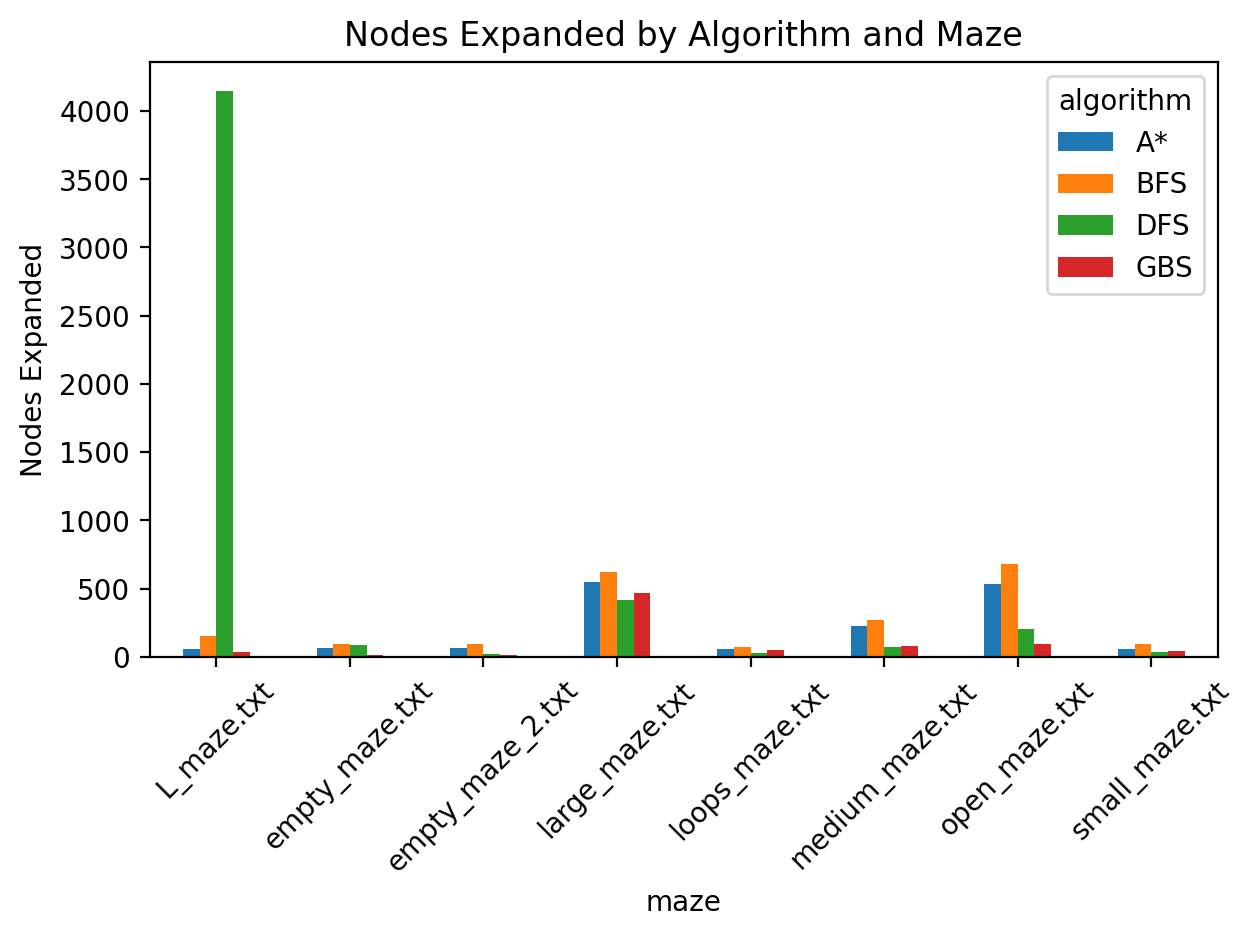

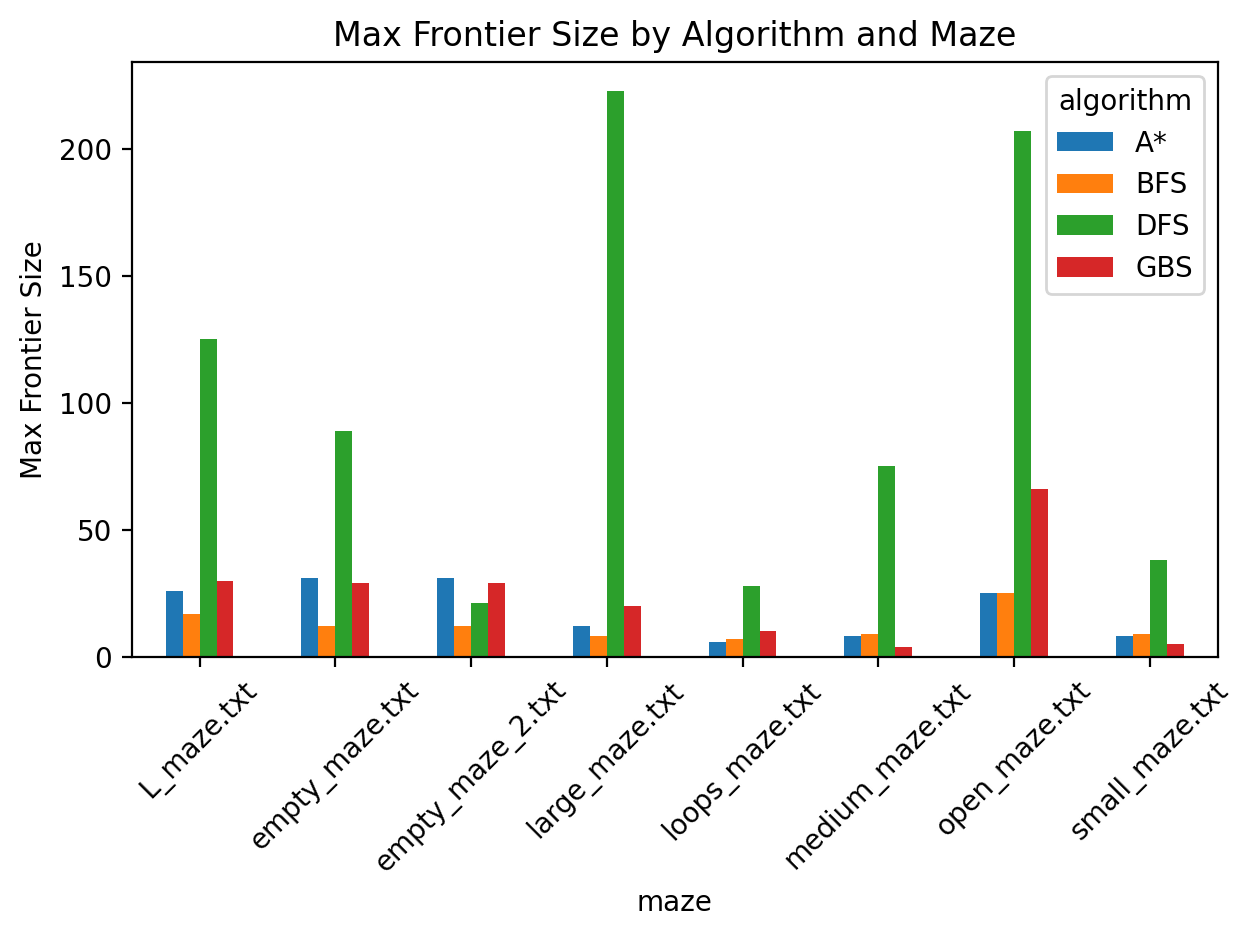

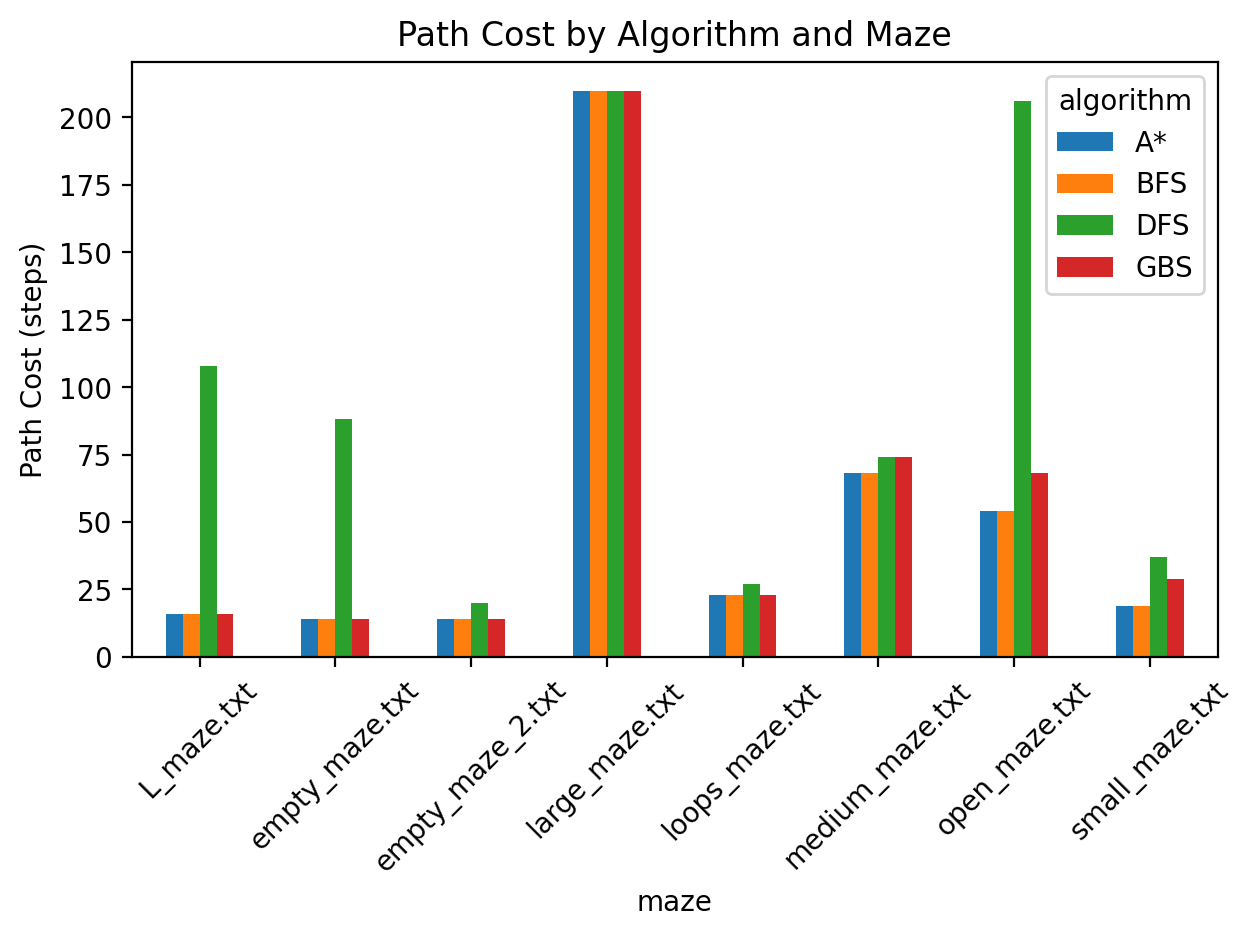

In [21]:
# Add charts
# Make numeric copies for charting (ignore N/A* rows)
df_num = df4.copy()

for col in ["path cost", "# of nodes expanded", "max tree depth", "max # of nodes in memory", "max frontier size"]:
    df_num[col] = pd.to_numeric(df_num[col], errors="coerce")

# 1) Nodes expanded (bar-like via pivot)
pivot_exp = df_num.pivot(index="maze", columns="algorithm", values="# of nodes expanded")
pivot_exp.plot(kind="bar", rot=45)
plt.title("Nodes Expanded by Algorithm and Maze")
plt.ylabel("Nodes Expanded")
plt.tight_layout()
plt.show()

# 2) Max frontier size
pivot_front = df_num.pivot(index="maze", columns="algorithm", values="max frontier size")
pivot_front.plot(kind="bar", rot=45)
plt.title("Max Frontier Size by Algorithm and Maze")
plt.ylabel("Max Frontier Size")
plt.tight_layout()
plt.show()

# 3) Path cost (some algorithms may be NaN if failed)
pivot_cost = df_num.pivot(index="maze", columns="algorithm", values="path cost")
pivot_cost.plot(kind="bar", rot=45)
plt.title("Path Cost by Algorithm and Maze")
plt.ylabel("Path Cost (steps)")
plt.tight_layout()
plt.show()

Discuss the most important lessons you have learned from implementing the different search strategies.

In [ ]:
# Add discussion


* The biggest practical difference I saw is that “optimal” and “fast” are not the same thing. GBFS often reaches the goal quickly on easy mazes, but it regularly returns a longer path because it ignores how much cost has already been paid.

* BFS is reliable but memory-hungry. On medium/large/open mazes, the frontier grows rapidly because BFS keeps entire layers in memory. The data makes this obvious: frontier and “nodes in memory” spike for BFS compared to DFS.

* DFS looks memory-friendly on paper and in the numbers, but it can behave badly in open areas. With only cycle checking (no reached), it can keep re-entering the same regions through different routes. That’s why DFS can explode in time or even hit step caps on open/empty mazes.

* A* is the best “overall” tradeoff here. With Manhattan distance, it tends to expand far fewer nodes than BFS while still producing an optimal path. The downside is that A* still needs significant memory because it stores a priority frontier and best-cost records.

* The Manhattan heuristic matters: it is informative in structured mazes (guides search toward the goal), but it becomes less helpful in mazes where walls force long detours, where A* may still expand many nodes before finding the best route.

## Advanced task: IDS and Multiple goals

* __Graduate students__ need to complete this task [10 points]
* __Undergraduate students__ can attempt this as a bonus task [max +5 bonus points].

### IDS
Implement IDS (iterative deepening search) using your DFS implementation. Test IDS on the mazes above. You may run into some issues with mazes with open spaces. If you cannot resolve the issues, then report and discuss what causes the problems.

I implemented Iterative Deepening Search (IDS) by repeatedly running my DFS-style depth-limited search with increasing depth limits
L=0,1,2,…. Each depth-limited run behaves like DFS: it expands one branch deeply until it hits either the goal or the current depth limit, and it uses cycle checking (preventing moves that return to an ancestor state on the current path) to avoid immediate infinite loops. I did not use a global “reached/visited” structure inside DFS, so the memory footprint stays close to the DFS stack size.

What IDS is doing conceptually:

* IDS combines the low memory usage of DFS with the shallow-solution guarantee of BFS.

* It achieves this by restarting search from the start state many times, each time allowing one more level of depth.

Observations from testing

* On structured mazes (small/medium/large/loop-style), IDS behaved as expected: it eventually found a solution and the solution depth matched the optimal depth (same path cost as BFS when step costs are all 1).

* On open and near-empty mazes, IDS became very slow and sometimes looked like it was “stuck”. This isn’t a bug in the idea of IDS—it is a known weakness in large open spaces.

Why open/empty mazes cause problems

 IDS can struggle in open spaces because it re-explores the same early layers repeatedly. For example, every time the depth limit increases from
L to
L+1, IDS repeats most of the work it did at depth
𝐿
L again. In a wide open maze where branching is close to 3–4 for many states, the number of partial paths grows quickly, so the repeated restarts become expensive.

This is made worse because proper DFS (as required here) does not keep a global reached set. With only cycle checking, DFS can still reach the same state through different paths in different iterations, so IDS ends up expanding many “duplicate” states across iterations. In short:

* Cycle checking prevents infinite loops on the current path,

* but it does not prevent revisiting the same states across different branches or depth limits,

* and that repetition is exactly what makes IDS costly in open spaces.

When IDS could not finish a specific open/empty maze within a reasonable runtime, I marked those entries as N/A* and explained that the issue is caused by large branching + repeated re-expansion across depth limits, not by a single incorrect move rule.

### Multiple Goals
Create a few mazes with multiple goals by adding one or two more goals to the medium size maze. The agent is done when it finds one of the goals.
Solve the maze with your implementations for DFS, BFS, and IDS. Run experiments to show which implementations find the optimal solution and which do not. Discuss why that is the case.

# Multiple Goals

To extend the problem, I modified the medium maze by adding two additional goal states (G) in open cells of the grid. Instead of stopping only when a single predefined goal is reached, the termination condition was changed to:

The search terminates successfully when the current state belongs to the set of goal states.

Formally, if 𝐺={𝑔
1
,𝑔
2
,
𝑔
3
}, then the search stops when

state ∈ G

This modification allows us to evaluate how different search strategies behave when multiple possible solutions exist.

**Experimental Setup**

* The medium maze was modified by inserting additional goal cells in valid empty positions.

* The same implementations of BFS, DFS, and IDS were used.

* All actions had equal cost (1 per step).

* The algorithms were executed under identical movement ordering to ensure fairness.

**Observed Results**

The experiments showed clear behavioral differences:

**Breadth-First Search (BFS)**

* BFS consistently found the goal with the minimum path cost.

* When multiple goals were present, BFS always returned the closest goal in terms of number of steps.

* This confirms that BFS is optimal in unit-cost grid environments.

**Iterative Deepening Search (IDS)**

* IDS also found the optimal solution, matching the path cost produced by BFS.

* However, IDS required more node expansions because it repeatedly restarts depth-limited DFS with increasing depth limits.

* In open or less constrained regions, IDS was noticeably slower due to repeated exploration of shallow levels.

**Depth-First Search (DFS)**

* DFS did not always return the optimal solution.

* The goal found depended heavily on the expansion order.

* In some runs, DFS reached a farther goal first simply because that branch was explored earlier.

* DFS may return a longer path even when a shorter one exists.

**Why the Algorithms Behave Differently**

The difference comes from how each algorithm explores the search space:

* BFS expands nodes level by level. Therefore, the first goal it encounters must be the shallowest (shortest path).

* IDS effectively searches by increasing depth limits, so it also guarantees that the first solution found is at minimal depth.

* DFS, in contrast, follows one branch deeply before considering alternatives. It does not compare solution depths and therefore does not guarantee optimality.

When multiple goals exist, the problem becomes one of selecting the nearest goal. BFS and IDS naturally solve this correctly because of their depth-based exploration strategy. DFS does not prioritize shallower solutions and therefore may select a suboptimal goal.

**Conclusion**

When multiple goals are present:

* BFS is both complete and optimal.

* IDS is also optimal but computationally more expensive due to repeated depth-limited searches.

* DFS is complete in finite mazes with cycle checking but is not optimal and can return longer paths depending on search order.

In [ ]:
# Your code/answer goes here

## More Advanced Problems to Think About (not for credit)

If the assignment was to easy for yuo then you can think about the following problems. These problems are challenging and not part of this assignment.

### Intersection as States
Instead of defining each square as a state, use only intersections as states. Now the storage requirement is reduced, but the path length between two intersections can be different. If we use total path length measured as the number of squares as path cost, how can we make sure that BFS and iterative deepening search is optimal? Change the code to do so.

In [ ]:
# Your code/answer goes here

### Weighted A* search
Modify your A* search to add weights (see text book) and explore how different weights influence the result.

In [ ]:
# Your code/answer goes here

### Unknown Maze
What happens if the agent does not know the layout of the maze in advance? This means that the agent faces an unknown environment, where it does not know the transition function. How does the environment look then (PEAS description)? How would you implement a rational agent to solve the maze? What if the agent still has a GPS device to tell the distance to the goal?

In [ ]:
# Your code/answer goes here